# ISAS2026 — Comparative Master Pipeline
## A Comparative Evaluation of Temporal Windowing and Validation Protocols for BLE-Based Indoor Localization in a Nursing Care Facility

This single notebook integrates the **entire pipeline** (preprocessing → feature engineering → windowing → evaluation → modeling → inference → sanity check) and is specifically designed to **compare** approaches, rather than merely selecting one:

1. **Windowing techniques** (3 families, each with 5 window size candidates: 5/10/15/20/25 seconds, excluding the raw baseline):
   - **A. Raw / no windowing** — every original RSSI row = 1 sample (baseline, similar to a teammate's approach).
   - **B. Raw windows with overlap** — 50% overlap windows, **every row within the window is preserved as is** (unaggregated) → the number of rows INCREASES (~2x at 50% overlap). This was the initial approach of the project.
   - **C. Aggregated windows** — non-overlapping windows, **each window is summarized into a single row** (mean/median/std/min/max/count per beacon + mean/std for engineered features) → the number of rows DECREASES significantly.
2. **Evaluation/split protocols**: Leave-One-Day-Out (LODO), Repeated Stratified Group K-Fold (grouped per visit), and Stratified random split (naive row-level baseline) — reported side-by-side so that the extent of score inflation due to inter-split data leakage is presented as quantifiable figures, rather than mere claims.
3. **Model comparison**: XGBoost, LightGBM, RandomForest, Logistic Regression, MLP (`sklearn.neural_network.MLPClassifier` — chosen over Keras/TensorFlow for RAM efficiency, see RAM notes below), plus **soft-vote ensemble** (probability averaging).

**Preprocessing & features are EXACTLY THE SAME across all branches** (Stages 1–3 below run ONCE, before the windowing branching) — ensuring that performance differences originate purely from the windowing/split/model, not from implicitly different feature sets.

### RAM Optimization (target: 12 GB laptop)
- All tables are saved as **Parquet** (instead of CSV) — smaller on disk, faster to read, and strictly preserves dtypes (no need to re-infer).
- Every large DataFrame is **downcasted** (`float64→float32`, etc.) immediately after creation (`ble_utils.ram_utils.downcast_numeric`).
- Windowing candidates are processed **ONE BY ONE**: built → saved to disk → cleared from memory (`gc.collect()`) — All 11 windowing candidates are NEVER held in RAM simultaneously.
- MLP uses `sklearn.neural_network.MLPClassifier` (not Keras/TensorFlow) — much lighter for 12 GB RAM and doesn't require a separate GPU/TF installation.
- LightGBM/XGBoost/RandomForest are constrained with reasonable `n_jobs` & `max_bin`/`max_depth` (configured in `CONFIG` below — lower them further if your laptop is more constrained than 12 GB).
- The most computationally expensive part (full model x split x all window candidates comparison) is behind the `RUN_FULL_MATRIX` flag — default is `False` so it can run quickly on a small scale before committing to a full overnight run.

### Usage Guide
1. Fill in `CONFIG['ble_path']` and `CONFIG['label_path']` below with your actual CSV paths. **If those files are not found, the notebook will automatically generate a small SYNTHETIC dataset** so the entire pipeline can still run end-to-end for logic verification (clearly marked with `WARNING: using SYNTHETIC data`) — do not trust the model metric results in this mode, it is purely to ensure the code runs.
2. Run all cells sequentially from the top.
3. Main tables for the paper are in Stage 6 (windowing ablation), Stage 7 (split ablation), Stage 8 (model comparison), and Stage 10 (sanity check).

## Stage 0 — Setup & Configuration

In [1]:
import sys, os, gc, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, '.')  # so `import ble_utils` works when this notebook lives at the project root

from ble_utils.data_merge import merge_ble_with_labels, verify_no_leakage
from ble_utils.cleaning import (
    RSSI_TO_ROOM, ROOM_LABEL_ALIASES, RSSI_MISSING_FLOOR,
    normalize_room_labels, replace_zero_rssi, build_full_rssi_to_room_mapping,
    verify_alias_group_similarity, verify_beacon_room_association, simple_rssi_pruning,
)
from ble_utils.features import extract_all_features, extract_packet_count_features, \
    extract_window_sequence_features, apply_scaler, DEFAULT_FEATURE_CONFIG
from ble_utils.windowing import (
    create_daily_windowed_dataset, create_daily_aggregated_dataset,
    build_visit_groups, filter_and_cap_visit_groups,
)
from ble_utils.evaluation import (
    evaluate_models, summarize_evaluate_models, iterate_splits,
    compute_clipped_class_weights, summarize_unseen_classes, merge_rare_rooms,
)
from ble_utils.postprocess import (
    build_room_adjacency_graph, temporal_smoothing,
    transition_constrained_correction, minority_rescue, viterbi_decode,
)
from ble_utils.ram_utils import (
    downcast_numeric, categorize_low_cardinality, save_parquet, free, track_ram,
    read_csv_optimized, current_ram_usage_mb,
)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RSSI_COLS = [f'RSSI_{i}' for i in range(1, 26)]

CONFIG = {
    # --- input data (EDIT THESE to your real paths) ---
    'ble_path': 'D:/ISAS 2026/dataset/ble_train_4d.csv',
    'label_path': 'D:/ISAS 2026/dataset/5f_label_loc_train.csv',
    'test_ble_path': 'D:/ISAS 2026/dataset/BLE_Test_predict.csv',

    # --- output dirs ---
    'processed_dir': 'processed',
    'models_dir': 'models',

    # --- windowing ---
    'window_sizes_sec': [5, 10, 15, 20, 25],
    'overlap_fraction': 0.5,   # for the RAW/overlap windowing branch (B)

    # --- evaluation ---
    'random_state': RANDOM_STATE,
    'rsgkf_n_splits': 5,
    'rsgkf_n_repeats': 6,        # bump to 5+ for the final paper run
    'stratrandom_n_splits': 5,
    'class_weight_max': 10.0,

    # --- speed/RAM knobs (lower these further on a more constrained machine) ---
    'quick_mode': False,          # small model sizes for fast iteration; flip False for final numbers
    'run_full_matrix': True,    # the expensive model x split x ALL window-candidates cell
    'n_jobs': -2,
    'use_gpu': True,
}

Path(CONFIG['processed_dir']).mkdir(exist_ok=True, parents=True)
Path(CONFIG['models_dir']).mkdir(exist_ok=True, parents=True)

print("Config loaded. quick_mode =", CONFIG['quick_mode'], "| run_full_matrix =", CONFIG['run_full_matrix'])

Config loaded. quick_mode = False | run_full_matrix = True


### 0.1 — Auto-logging for notebook outputs + figure saving utility

The cell below **only needs to be run once** (at the very top, before any other cells) and automatically makes *every subsequent cell* log its code + output (print, DataFrame/table, error) to `outputs/logs/full_notebook_log.{md,txt,csv}` without requiring manual copy-pasting. Tables/DataFrames are automatically rendered as monospace text tables. This cell also provides `save_figure(fig, name, description)` which is used by all graph cells below to save figures to `outputs/figures/<fixed_name>.{png,pdf,svg}` (dpi=300, `bbox_inches='tight'`, the filename is **fixed/descriptive, not random**) while simultaneously recording it to `outputs/logs/figures_manifest.csv`.

In [ ]:
# =============================================================================
# AUTO-LOGGING & FIGURE-OUTPUT UTILITIES (do not delete / do not move)
# -----------------------------------------------------------------------------
# Once executed, this cell makes every SUBSEQUENT cell automatically log
# its code + output (print, DataFrame, error) to:
#   outputs/logs/full_notebook_log.md   -> tables/DataFrames rendered as
#                                          monospace text tables (```text``` block)
#   outputs/logs/full_notebook_log.txt  -> plain-text version (no markdown)
#   outputs/logs/full_notebook_log.csv  -> one row per cell (to open
#                                          in Excel/Sheets if needed)
# No need to manually copy-paste outputs anymore -- just run the notebook from
# top to bottom, everything is recorded automatically, completely, in cell order.
#
# The `save_figure(fig, name, description)` function is used in the graph cells
# below to save figures to outputs/figures/<name>.png/.pdf/.svg with
# FIXED NAMES (deterministic, not random/hash names) so they are easy to
# reference in the paper/Overleaf/Word, plus automatically logged in
# outputs/logs/figures_manifest.csv.
# =============================================================================
import sys, os, io, csv, json, warnings
from datetime import datetime
import numpy as np
import pandas as pd
from IPython import get_ipython
import IPython.display as _ipy_display_module

# ---- output folders ----------------------------------------------------------
OUTPUT_DIR = "outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
LOG_DIR = os.path.join(OUTPUT_DIR, "logs")
for _d in (OUTPUT_DIR, FIG_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

LOG_MD_PATH = os.path.join(LOG_DIR, "full_notebook_log.md")
LOG_TXT_PATH = os.path.join(LOG_DIR, "full_notebook_log.txt")
LOG_CSV_PATH = os.path.join(LOG_DIR, "full_notebook_log.csv")
FIG_MANIFEST_PATH = os.path.join(LOG_DIR, "figures_manifest.csv")

MAX_LOG_CHARS = 60_000  # safe limit per section so the log file doesn't blow up


def _truncate(text: str, limit: int = MAX_LOG_CHARS) -> str:
    if text is None:
        return ""
    if len(text) <= limit:
        return text
    return text[:limit] + f"\n... [truncated, {len(text) - limit} more characters -- see original output in notebook]"


def df_to_monospace(df, max_rows: int = 300) -> str:
    """Render DataFrame/Series as a monospace text table (neat for .md/.txt/paper)."""
    if isinstance(df, pd.Series):
        df = df.to_frame()
    truncated_note = ""
    if len(df) > max_rows:
        truncated_note = f"\n... ({len(df) - max_rows} more rows not shown, total {len(df)} rows)"
    try:
        from tabulate import tabulate  # optional dependency, yields neater results if available
        table_str = tabulate(df.head(max_rows), headers="keys", tablefmt="psql", showindex=True)
    except ImportError:
        with pd.option_context("display.max_columns", None, "display.width", 200):
            table_str = df.head(max_rows).to_string()
    return table_str + truncated_note


def save_figure(fig=None, name: str = "figure", description: str = ""):
    """Save matplotlib figure to outputs/figures/<name>.{png,pdf,svg} with
    FIXED NAME (according to the `name` parameter, not random/hashed), dpi=300,
    bbox_inches='tight' (safe for LaTeX/Overleaf & Word), then record it in
    outputs/logs/figures_manifest.csv. Returns its path dict."""
    import matplotlib.pyplot as plt
    if fig is None:
        fig = plt.gcf()
    paths = {}
    for ext in ("png", "pdf", "svg"):
        p = os.path.join(FIG_DIR, f"{name}.{ext}")
        fig.savefig(p, dpi=300, bbox_inches="tight")
        paths[ext] = p

    row = {
        "figure_name": name,
        "png_path": paths["png"],
        "pdf_path": paths["pdf"],
        "svg_path": paths["svg"],
        "description": description,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }
    write_header = not os.path.exists(FIG_MANIFEST_PATH)
    with open(FIG_MANIFEST_PATH, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            w.writeheader()
        w.writerow(row)

    print(f"[FIGURE SAVED] {name}\n  -> {paths['png']}\n  -> {paths['pdf']}\n  -> {paths['svg']}")
    return paths


# ---- auto-capture mechanism per cell ----------------------------------------
class _TeeStream(io.TextIOBase):
    """Write to the original stream (so the output still appears normally in the notebook)
    SIMULTANEOUSLY to an internal buffer (so it can be copied to the log file)."""
    def __init__(self, *streams):
        self._streams = streams

    def write(self, s):
        for st in self._streams:
            try:
                st.write(s)
            except Exception:
                pass
        return len(s)

    def flush(self):
        for st in self._streams:
            try:
                st.flush()
            except Exception:
                pass

    def isatty(self):
        return False


_capture_state = {}
_displayed_objects = []
_orig_display_fn = _ipy_display_module.display


def _logging_display(*objs, **kwargs):
    for o in objs:
        _displayed_objects.append(o)
    return _orig_display_fn(*objs, **kwargs)


def _format_any_output(obj):
    """Convert 1 output object to (label, text). Table -> monospace automatically."""
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        return "Table (monospace)", df_to_monospace(obj)
    if isinstance(obj, (dict, list, tuple)):
        try:
            return "Output (repr)", json.dumps(obj, indent=2, default=str, ensure_ascii=False)
        except Exception:
            return "Output (repr)", repr(obj)
    return "Output (repr)", repr(obj)


def _pre_run_cell(info):
    _capture_state["orig_stdout"] = sys.stdout
    _capture_state["orig_stderr"] = sys.stderr
    _capture_state["buf_stdout"] = io.StringIO()
    _capture_state["buf_stderr"] = io.StringIO()
    sys.stdout = _TeeStream(_capture_state["orig_stdout"], _capture_state["buf_stdout"])
    sys.stderr = _TeeStream(_capture_state["orig_stderr"], _capture_state["buf_stderr"])
    _capture_state["source"] = info.raw_cell
    _capture_state["start_ts"] = datetime.now()
    _displayed_objects.clear()


def _post_run_cell(result):
    sys.stdout = _capture_state.get("orig_stdout", sys.stdout)
    sys.stderr = _capture_state.get("orig_stderr", sys.stderr)

    src = (_capture_state.get("source") or "").strip()
    if not src:
        return

    stdout_text = _capture_state["buf_stdout"].getvalue()
    stderr_text = _capture_state["buf_stderr"].getvalue()
    ts = _capture_state["start_ts"].strftime("%Y-%m-%d %H:%M:%S")
    exec_count = result.execution_count

    extra_blocks = []  # list of (label, text) for objects from display()/return value

    for obj in list(_displayed_objects):
        extra_blocks.append(_format_any_output(obj))

    if getattr(result, "result", None) is not None:
        label, text = _format_any_output(result.result)
        extra_blocks.append((f"{label} (return value)", text))

    has_error = result.error_in_exec is not None

    # ---- write to .md ----
    md = [f"\n\n## Cell [{exec_count}] -- {ts}\n"]
    md.append("**Code:**\n```python\n" + _truncate(src) + "\n```\n")
    if stdout_text.strip():
        md.append("**Output (stdout):**\n```text\n" + _truncate(stdout_text.rstrip()) + "\n```\n")
    for label, text in extra_blocks:
        md.append(f"**{label}:**\n```text\n" + _truncate(text) + "\n```\n")
    if stderr_text.strip():
        md.append("**Stderr/Warning:**\n```text\n" + _truncate(stderr_text.rstrip()) + "\n```\n")
    if has_error:
        md.append(f"**Execution ERROR:** `{result.error_in_exec}`\n")
    with open(LOG_MD_PATH, "a", encoding="utf-8") as f:
        f.write("".join(md))

    # ---- write to .txt ----
    txt = [f"\n{'=' * 80}\nCELL [{exec_count}] -- {ts}\n{'=' * 80}\n"]
    txt.append("--- CODE ---\n" + _truncate(src) + "\n")
    if stdout_text.strip():
        txt.append("--- STDOUT ---\n" + _truncate(stdout_text.rstrip()) + "\n")
    for label, text in extra_blocks:
        txt.append(f"--- {label.upper()} ---\n" + _truncate(text) + "\n")
    if stderr_text.strip():
        txt.append("--- STDERR/WARNING ---\n" + _truncate(stderr_text.rstrip()) + "\n")
    if has_error:
        txt.append(f"--- ERROR --- \n{result.error_in_exec}\n")
    with open(LOG_TXT_PATH, "a", encoding="utf-8") as f:
        f.write("".join(txt))

    # ---- write to .csv (1 concise row per cell) ----
    combined_extra = "\n\n".join(t for _, t in extra_blocks)
    row = {
        "execution_count": exec_count,
        "timestamp": ts,
        "code_preview": src.replace("\n", " ")[:300],
        "stdout_preview": stdout_text.strip().replace("\n", " ")[:2000],
        "output_preview": combined_extra.replace("\n", " ")[:2000],
        "error": str(result.error_in_exec) if has_error else "",
    }
    write_header = not os.path.exists(LOG_CSV_PATH)
    with open(LOG_CSV_PATH, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            w.writeheader()
        w.writerow(row)


_ip = get_ipython()
if _ip is not None and not getattr(_ip, "_ble_autolog_registered", False):
    _ip.events.register("pre_run_cell", _pre_run_cell)
    _ip.events.register("post_run_cell", _post_run_cell)
    _ip.user_ns["display"] = _logging_display
    _ipy_display_module.display = _logging_display
    _ip._ble_autolog_registered = True
    print(f"[AUTO-LOG ACTIVE] All subsequent cell outputs will be automatically saved to:\n"
          f"  - {LOG_MD_PATH}\n  - {LOG_TXT_PATH}\n  - {LOG_CSV_PATH}\n"
          f"Figures will be saved to the folder: {FIG_DIR}/ (recorded in {FIG_MANIFEST_PATH})")
else:
    print("[AUTO-LOG] Already active previously -- not registered twice.")

[AUTO-LOG AKTIF] Semua output cell selanjutnya otomatis tersimpan ke:
  - outputs\logs\full_notebook_log.md
  - outputs\logs\full_notebook_log.txt
  - outputs\logs\full_notebook_log.csv
Gambar akan tersimpan ke folder: outputs\figures/ (dicatat di outputs\logs\figures_manifest.csv)


### Data loading (real data if available, synthetic if not)

If `CONFIG['ble_path']`/`CONFIG['label_path']` are not found, the cell below will generate a small synthetic dataset (a few days, a few rooms, random RSSI with room-specific patterns) — **purely so the entire pipeline can run end-to-end to verify code correctness**, NOT for trusting the output numbers. Once the actual files are available at the configured paths, this cell will automatically use them without any code changes.

In [ ]:
def _make_synthetic_ble_and_labels(n_days=5, rows_per_day=6000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    rooms = ['501', '502', '503', 'cafeteria', 'nurse station', 'kitchen', 'cleaning', 'toilet', '510', '511']
    room_dominant_beacon = {r: (i % 25) + 1 for i, r in enumerate(rooms)}

    ble_rows, label_rows = [], []
    for d in range(n_days):
        day = pd.Timestamp('2023-04-10') + pd.Timedelta(days=d)
        day_start = day + pd.Timedelta(hours=8)
        t = day_start
        session_id = 0
        while (t - day_start).total_seconds() < rows_per_day * 2:
            room = rooms[rng.randint(0, len(rooms))]
            dwell_rows = rng.randint(20, 150)
            session_start = t
            for _ in range(dwell_rows):
                row = {'user_id': 97, 'timestamp': t, 'year_month_day': str(day.date()),
                       'mac address': rng.randint(1, 26), 'RSSI': None, 'power': -59, 'hour': t.hour}
                # long-format single reading per row, like the real BLE export
                dom_beacon = room_dominant_beacon[room]
                mac = row['mac address']
                if mac == dom_beacon:
                    rssi = int(np.clip(rng.normal(-45, 6), -90, -20))
                else:
                    rssi = int(np.clip(rng.normal(-95, 8), -108, -60))
                row['RSSI'] = rssi if rng.rand() > 0.05 else 0  # ~5% zero/undetected
                ble_rows.append(row)
                t += pd.Timedelta(seconds=rng.choice([1, 1, 1, 2]))
            session_end = t
            label_rows.append({'user_id': 90, 'started_at': session_start, 'finished_at': session_end,
                                'room': room, 'floor': 5, 'deleted_at': None})
            session_id += 1

    df_ble = pd.DataFrame(ble_rows)
    df_label = pd.DataFrame(label_rows)
    df_label['started_at'] = pd.to_datetime(df_label['started_at']).dt.tz_localize('Asia/Tokyo')
    df_label['finished_at'] = pd.to_datetime(df_label['finished_at']).dt.tz_localize('Asia/Tokyo')
    return df_ble, df_label


USING_SYNTHETIC_DATA = not (Path(CONFIG['ble_path']).exists() and Path(CONFIG['label_path']).exists())

if USING_SYNTHETIC_DATA:
    print("WARNING: using SYNTHETIC data (actual files not found at CONFIG['ble_path']/['label_path']).")
    print("         Model metric results in this notebook MEAN NOTHING until you provide the actual data paths.")
    df_ble_raw, df_label_raw = _make_synthetic_ble_and_labels()
else:
    dtype_map = {'user_id': 'int32', 'mac address': 'int16', 'RSSI': 'int16', 'power': 'int32'}
    df_ble_raw = read_csv_optimized(CONFIG['ble_path'], dtype_map=dtype_map)
    df_label_raw = pd.read_csv(CONFIG['label_path'])

print("df_ble_raw:", df_ble_raw.shape, "| df_label_raw:", df_label_raw.shape)

Loaded D:/ISAS 2026/dataset/ble_train_4d.csv: 1,673,395 rows x 33 cols, 435.7 MB in memory
df_ble_raw: (1673395, 33) | df_label_raw: (1334, 11)


> **Note on long vs wide format:** Raw BLE data typically comes in **long** format (`user_id, timestamp, mac address, RSSI, ...`, where one row = one reading from ONE beacon). The following cell *pivots* this to **wide** format (`RSSI_1..RSSI_25`, where one row = one snapshot of ALL beacons at a given time) if the data is not already in that shape — this pivot is done directly by integer index (not hex MAC lookup).

In [4]:
def pivot_long_to_wide(df_long: pd.DataFrame) -> pd.DataFrame:
    '''long (user_id, timestamp, mac address, RSSI, ...) -> wide (RSSI_1..25).
    `mac address` here is assumed to already be the integer beacon index (1..25),
    matching the official test-CSV format described in the project README.'''
    if any(c.startswith('RSSI_') for c in df_long.columns):
        return df_long  # already wide

    meta_cols = [c for c in df_long.columns if c not in ('mac address', 'RSSI')]
    pivoted = df_long.pivot_table(
        index=meta_cols, columns='mac address', values='RSSI', aggfunc='first',
    )
    pivoted.columns = [f'RSSI_{int(c)}' for c in pivoted.columns]
    pivoted = pivoted.reset_index()
    for c in RSSI_COLS:
        if c not in pivoted.columns:
            pivoted[c] = 0  # beacon never seen in this slice -> undetected
    return pivoted


df_ble = pivot_long_to_wide(df_ble_raw)
df_ble = downcast_numeric(df_ble)
print("df_ble (wide):", df_ble.shape)
df_ble.head(3)

downcast_numeric: 435.7 MB -> 130.9 MB (70% reduction)
df_ble (wide): (1673395, 33)


,Unnamed: 0,user_id,timestamp,mac address,RSSI,power,year_month_day,hour,RSSI_1,RSSI_2,...,RSSI_16,RSSI_17,RSSI_18,RSSI_19,RSSI_20,RSSI_21,RSSI_22,RSSI_23,RSSI_24,RSSI_25
0,0,90,2023-04-10 13:00:00,4,-91,-2147483648,2023-04-10,13,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,90,2023-04-10 13:00:00,4,-92,-2147483648,2023-04-10,13,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,90,2023-04-10 13:00:00,4,-91,-2147483648,2023-04-10,13,0,0,...,0,0,0,0,0,0,0,0,0,0


## Stage 1 — Data Preparation

Merge raw BLE with room labels (inner join based on session time range, per `user_id`) → normalize label aliases → drop corrupted/duplicate rows. **This stage runs ONCE and the results are used by ALL windowing branches** below.

In [ ]:
# Align user_id between the two tables if they differ (official data for this project: BLE
# uses user_id 97, labels use user_id 90, for THE SAME PERSON) --
# `merge_ble_with_labels` itself doesn't do this (purely time-based join),
# so it must be done explicitly here first, before merging.
df_label_aligned = df_label_raw.copy()
if 'deleted_at' in df_label_aligned.columns:
    df_label_aligned = df_label_aligned[df_label_aligned['deleted_at'].isna()].copy()

ble_users = set(df_ble['user_id'].unique())
label_users = set(df_label_aligned['user_id'].unique())

# Official project pairs: {user_id in label : user_id in BLE for the same person}
KNOWN_USER_PAIRS = {97: 90}   # add other pairs here if there are other BLE files

if ble_users != label_users:
    if len(ble_users) != 1:
        raise ValueError(f"df_ble has more than 1 user_id: {ble_users} — not supported by this guard")

    only_ble_user = next(iter(ble_users))
    matching_label_id = next((lid for lid, bid in KNOWN_USER_PAIRS.items() if bid == only_ble_user), None)

    if matching_label_id is None or matching_label_id not in label_users:
        raise ValueError(
            f"No official pair found for BLE user_id {only_ble_user} "
            f"among label user_id {label_users}. Check KNOWN_USER_PAIRS."
        )

    print(f"Aligning user_id: label {matching_label_id} -> BLE {only_ble_user} "
          f"(other users in label: {label_users - {matching_label_id}} ignored, not this person)")
    df_label_aligned = df_label_aligned[df_label_aligned['user_id'] == matching_label_id].copy()
    df_label_aligned['user_id'] = only_ble_user

df_ble['timestamp'] = pd.to_datetime(df_ble['timestamp'])

df_label_aligned['started_at'] = pd.to_datetime(df_label_aligned['started_at']).dt.tz_localize(None)
df_label_aligned['finished_at'] = pd.to_datetime(df_label_aligned['finished_at']).dt.tz_localize(None)

# Proceed with merge
merged_df = merge_ble_with_labels(df_ble, df_label_aligned)
verify_no_leakage(merged_df, df_label_raw)

merged_df = merge_ble_with_labels(df_ble, df_label_aligned)
verify_no_leakage(merged_df, df_label_raw)

_ = verify_alias_group_similarity(merged_df, RSSI_COLS, {'toilet_group': ROOM_LABEL_ALIASES['toilet']})
if 'RSSI_25' in merged_df.columns:
    _ = verify_beacon_room_association(merged_df, 'RSSI_25', 'cafeteria')

merged_df = normalize_room_labels(merged_df)
merged_df = merged_df.dropna(subset=['room']).drop_duplicates()
merged_df = downcast_numeric(merged_df)
merged_df = categorize_low_cardinality(merged_df, ['room', 'floor', 'year_month_day'])

print(f"merged_df final: {merged_df.shape}, {merged_df['room'].nunique()} rooms, "
      f"{merged_df['year_month_day'].nunique()} days")
save_parquet(merged_df, f"{CONFIG['processed_dir']}/merged_labeled.parquet")

Menyamakan user_id: label 97 -> BLE 90 (user lain di label: {np.int64(91), np.int64(38)} diabaikan, bukan orang ini)
Merge OK: 1,135,757 labeled BLE records from 454 label sessions (inner join, no leakage)

=== DATA LEAKAGE CHECK ===
OK: all merged rooms exist in labels
NOTE: 1,056 merged rows have a missing (NaN) room label — drop these before training (handled in Notebook 1's cleaning step).
OK: every timestamp is inside its label window

--- Summary ---
Labeled BLE records : 1,135,757
Label sessions       : 1334
Unique users          : 1
Unique rooms          : 22
Unique floors         : 2
Merge OK: 1,135,757 labeled BLE records from 454 label sessions (inner join, no leakage)

=== DATA LEAKAGE CHECK ===
OK: all merged rooms exist in labels
NOTE: 1,056 merged rows have a missing (NaN) room label — drop these before training (handled in Notebook 1's cleaning step).
OK: every timestamp is inside its label window

--- Summary ---
Labeled BLE records : 1,135,757
Label sessions       : 1

### 1.1 — [FIGURE] Class Distribution: Before vs After Label Consolidation

A horizontal bar chart displaying the dominance of *majority classes* (e.g., `nurse station`, `kitchen`, `cafeteria`) compared to *minority classes* (5xx rooms) -- both in the raw labels (before aliases/variant names are merged by `normalize_room_labels`) and afterward. This is the foundational reason why Macro F1 (rather than accuracy) is used as the primary metric throughout this notebook.

[FIGURE SAVED] fig01_distribusi_kelas_sebelum_sesudah_konsolidasi
  -> outputs\figures\fig01_distribusi_kelas_sebelum_sesudah_konsolidasi.png
  -> outputs\figures\fig01_distribusi_kelas_sebelum_sesudah_konsolidasi.pdf
  -> outputs\figures\fig01_distribusi_kelas_sebelum_sesudah_konsolidasi.svg


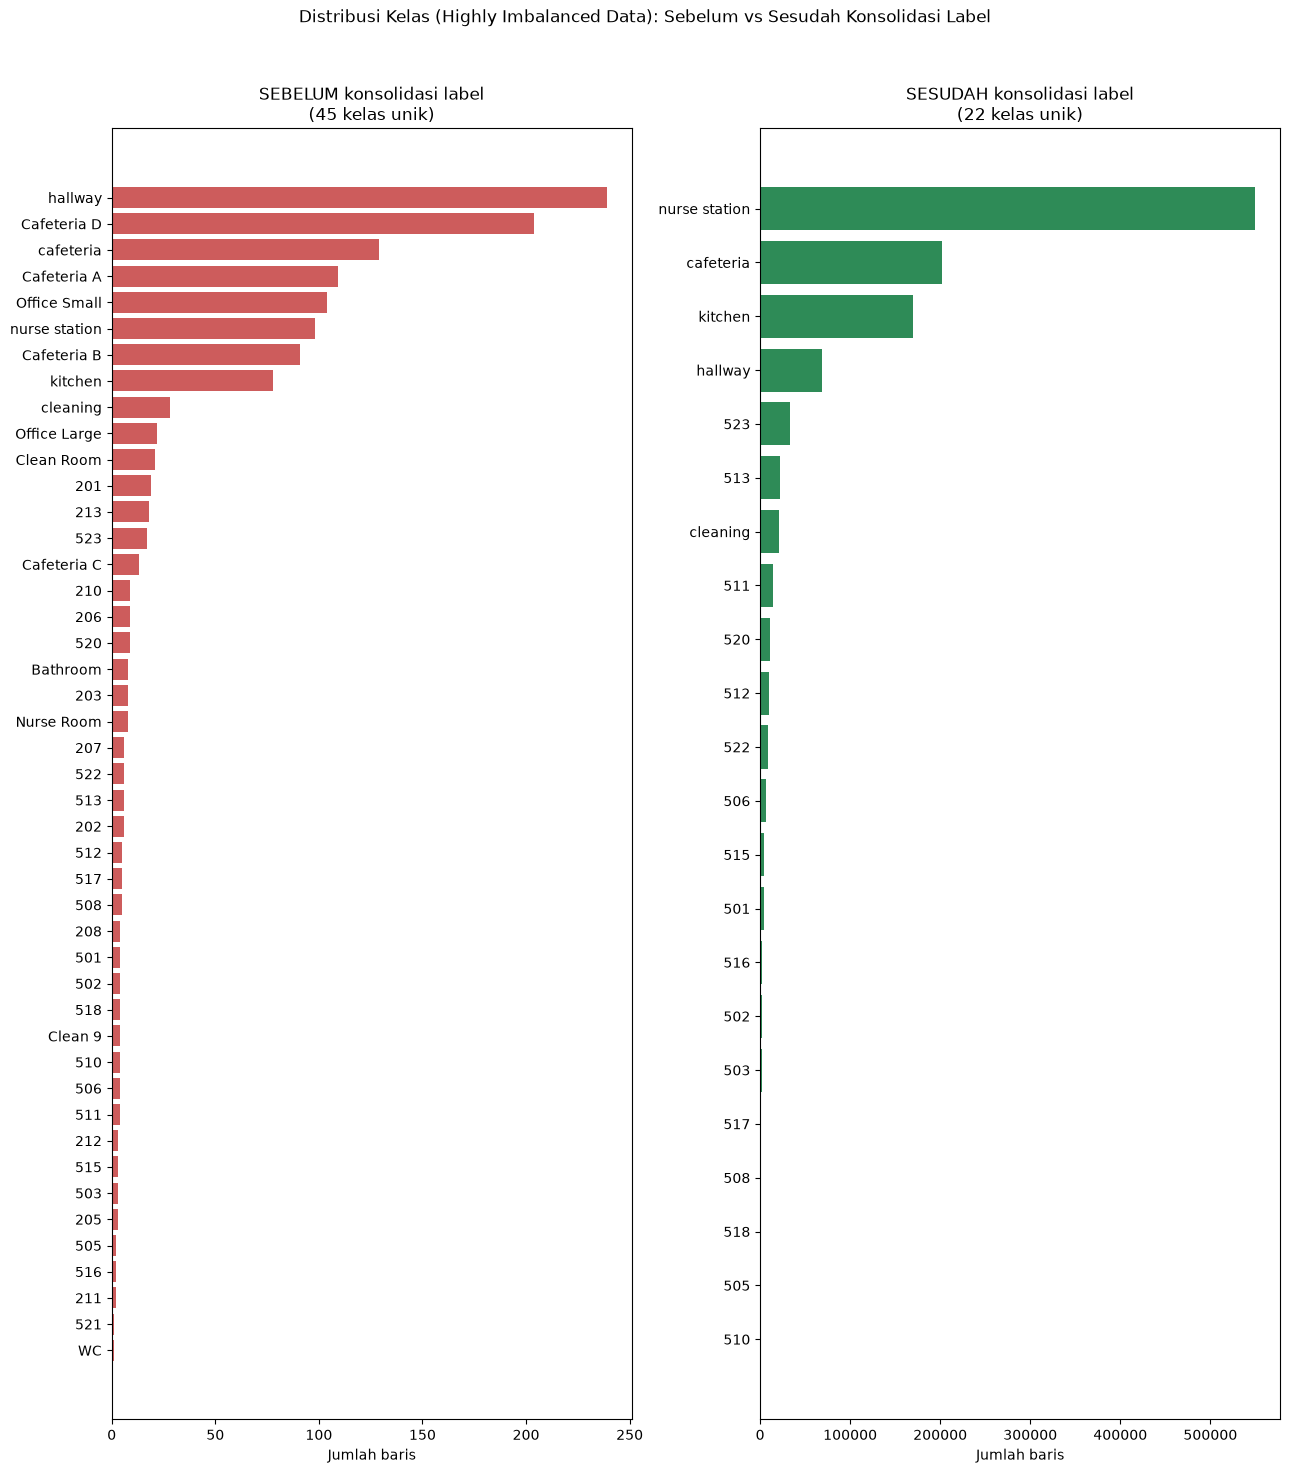


Ringkasan (top 5 & bottom 5) SEBELUM konsolidasi:
               count
room                
hallway          239
Cafeteria D      204
cafeteria        129
Cafeteria A      109
Office Small     104
nurse station     98
Cafeteria B       91
kitchen           78
cleaning          28
Office Large      22
Clean Room        21
201               19
213               18
523               17
Cafeteria C       13
520                9
206                9
210                9
203                8
Nurse Room         8
Bathroom           8
522                6
513                6
202                6
207                6
517                5
508                5
512                5
Clean 9            4
208                4
510                4
506                4
511                4
502                4
501                4
518                4
212                3
515                3
205                3
503                3
211                2
505                2
516                2
WC  

In [ ]:
# [FIGURE 1] Class distribution -- BEFORE (raw label, before aliases are merged
# by normalize_room_labels) vs AFTER (merged_df['room'], already consolidated
# + dropna + dedup) -- horizontal bar chart because room names are quite long.
import matplotlib.pyplot as plt

before_counts = df_label_raw['room'].value_counts().sort_values(ascending=True)
after_counts = merged_df['room'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.32 * max(len(before_counts), len(after_counts)))))

axes[0].barh(before_counts.index.astype(str), before_counts.values, color='indianred')
axes[0].set_title(f"BEFORE label consolidation\n({before_counts.shape[0]} unique classes)")
axes[0].set_xlabel("Row count")

axes[1].barh(after_counts.index.astype(str), after_counts.values, color='seagreen')
axes[1].set_title(f"AFTER label consolidation\n({after_counts.shape[0]} unique classes)")
axes[1].set_xlabel("Row count")

fig.suptitle("Class Distribution (Highly Imbalanced Data): Before vs After Label Consolidation", y=1.02)
plt.tight_layout()

save_figure(
    fig, "fig01_distribusi_kelas_sebelum_sesudah_konsolidasi",
    "Horizontal bar chart of class distribution (room) before vs after normalize_room_labels; "
    "showing majority classes (nurse station/kitchen/cafeteria) vs minority classes (5xx rooms)."
)
plt.show()

print("\nSummary (top 5 & bottom 5) BEFORE consolidation:")
print(df_to_monospace(before_counts.sort_values(ascending=False)))
print("\nSummary (top 5 & bottom 5) AFTER consolidation:")
print(df_to_monospace(after_counts.sort_values(ascending=False)))

## Stage 2 — Preprocessing & Cleaning

RSSI `0` (invalid/undetected) → floored to `-108`. Followed by per-room noise-pruning: other beacons that are read as strong as or stronger than the room's own dominant beacon (95th percentile) are considered noise/reflections and pruned. The beacon↔room mapping is compiled from the official floor plan + empirical fallback for rooms not present in the floor plan (`build_full_rssi_to_room_mapping`, calculated **after** RSSI 0 is floored — this order is crucial, see the function's docstring).

In [7]:
preprocessed_df = replace_zero_rssi(merged_df, RSSI_COLS, floor=RSSI_MISSING_FLOOR)

full_mapping = build_full_rssi_to_room_mapping(preprocessed_df, RSSI_COLS)
preprocessed_df, prune_stats = simple_rssi_pruning(preprocessed_df, rssi_to_room_mapping=full_mapping)

preprocessed_df = downcast_numeric(preprocessed_df)
print("preprocessed_df:", preprocessed_df.shape)
save_parquet(preprocessed_df, f"{CONFIG['processed_dir']}/preprocessed.parquet")
free(merged_df); merged_df = None

derive_room_to_dominant_beacon: inferred beacon for 1 unmapped room(s): {'hallway': 'RSSI_20'}
Processing 22 unique rooms...
  kitchen             : pruned 3,600 values (threshold -86.00)
  cafeteria           : pruned 26,166 values (threshold -88.00)
  cleaning            : pruned 962 values (threshold -84.00)
  nurse station       : pruned 24,134 values (threshold -89.00)
  skip hallway: no beacon mapping found
  501                 : pruned 903 values (threshold -90.00)
  506                 : pruned 1,418 values (threshold -91.00)
  520                 : pruned 1,786 values (threshold -90.00)
  511                 : pruned 8,912 values (threshold -95.00)
  523                 : pruned 2,990 values (threshold -86.00)
  516                 : pruned 255 values (threshold -84.00)
  508                 : pruned 33 values (threshold -87.00)
  512                 : pruned 4,615 values (threshold -94.00)
  522                 : pruned 1,376 values (threshold -88.00)
  502                 :

## Stage 3 — Feature Engineering & Normalization (per day)

All 5 feature families (statistical, spatial, temporal dynamics, distance estimation, visit-time) are computed **per `year_month_day`** (not once for the entire data) — ensuring that temporal/rolling features do not "leak" across overnight data collection gaps. Afterwards, Min-Max scaling `[0,1]` is applied **only** to the raw `RSSI_1..25`.

**The output of this stage (`features_normalized`) is the branching point**: the rows below it are identical for all three windowing families (A/B/C) — windowing differences purely occur AFTER this point.

In [8]:
def extract_features_per_day(df, rssi_cols, feature_config=None, day_col='year_month_day'):
    daily_frames = []
    for day, day_df in df.groupby(day_col, sort=False):
        day_df_sorted = day_df.sort_values('timestamp').reset_index(drop=True)
        day_feat = extract_all_features(day_df_sorted, rssi_cols, feature_config=feature_config)
        daily_frames.append(day_feat)
    return pd.concat(daily_frames, ignore_index=True)


with track_ram("feature engineering (per day)"):
    features_df = extract_features_per_day(preprocessed_df, RSSI_COLS, DEFAULT_FEATURE_CONFIG)

features_df, rssi_scaler = apply_scaler(features_df, RSSI_COLS, scaler_type='minmax')
features_df = downcast_numeric(features_df)

import joblib
joblib.dump(rssi_scaler, f"{CONFIG['models_dir']}/rssi_scaler.pkl")

print("features_df:", features_df.shape)
save_parquet(features_df, f"{CONFIG['processed_dir']}/features_normalized.parquet")
free(preprocessed_df); preprocessed_df = None

# columns that are NOT raw RSSI and NOT metadata -- these are the "engineered
# feature" columns aggregated with mean/std (not the full 6-stat set) in
# branch C below.
ENGINEERED_FEATURE_COLS = [
    c for c in features_df.columns
    if c not in RSSI_COLS and c not in (
        'user_id', 'mac address', 'RSSI', 'power', 'hour', 'timestamp',
        'year_month_day', 'room', 'floor', 'started_at', 'finished_at', 'duration_min',
    )
]
print(f"{len(ENGINEERED_FEATURE_COLS)} engineered feature columns (post feature-engineering, pre-windowing)")

Feature extraction: (600974, 38) -> (600974, 245) (+207 feature columns)
Feature extraction: (341813, 38) -> (341813, 245) (+207 feature columns)
Feature extraction: (160503, 38) -> (160503, 245) (+207 feature columns)
Feature extraction: (31411, 38) -> (31411, 245) (+207 feature columns)
[feature engineering (per day)] 20.5s, RAM 983 -> 2516 MB (delta +1533 MB)
downcast_numeric: 1562.7 MB -> 878.8 MB (44% reduction)
features_df: (1134701, 245)
Saved processed/features_normalized.parquet (1,134,701 rows x 245 cols, 38.0 MB on disk)
208 engineered feature columns (post feature-engineering, pre-windowing)


## Stage 4 — Three Windowing Branches

These are built **one by one**, immediately saved to Parquet, and then removed from memory before the next candidate is built — ensuring that all 11 candidates (1 raw + 5 overlap + 5 aggregated) are never held simultaneously in RAM.

Non-feature metadata/ID columns (`user_id`, `mac address`, single `RSSI`, `timestamp`, etc.) are dropped here — **`year_month_day` is intentionally retained** (used as the LODO fold key in Stages 6-8), and is only completely removed from the feature matrix right before `.fit()` inside `evaluate_models`.

In [9]:
COLUMNS_TO_DROP_POST_WINDOW = [
    'user_id', 'mac address', 'RSSI', 'power', 'hour', 'duration_min',
    'timestamp', 'floor', 'started_at', 'finished_at', 'window_start_ts', 'window_end_ts',
]

def finalize_candidate(df, extra_drop=()):
    drop = [c for c in (*COLUMNS_TO_DROP_POST_WINDOW, *extra_drop) if c in df.columns]
    df = df.drop(columns=drop)
    return downcast_numeric(df, verbose=False)


candidate_paths = {}   # name -> parquet path
candidate_shapes = {}  # name -> (rows, cols)

### Branch A — Raw / no windowing (baseline)

No window at all: each row in `features_normalized` is used exactly as it is as a single sample. This is the main comparison baseline — similar to the teammate's initial approach before they adopted the 20-second window.

In [10]:
with track_ram("branch A: raw (no windowing)"):
    features_full = pd.read_parquet(f"{CONFIG['processed_dir']}/features_normalized.parquet")
    cand_a = finalize_candidate(features_full)
    # no window_id/visit concept for the un-windowed baseline -- give every row
    # its own singleton group so `group_col` still works generically in evaluate_models
    cand_a['room_group_id'] = cand_a['year_month_day'].astype(str) + '_row' + cand_a.index.astype(str)
    path = f"{CONFIG['processed_dir']}/candidate_raw_no_window.parquet"
    save_parquet(cand_a, path)
    candidate_paths['raw_no_window'] = path
    candidate_shapes['raw_no_window'] = cand_a.shape
    free(cand_a); cand_a = None
    del features_full
    gc.collect()

C:\Users\Gilang\AppData\Local\Temp\ipykernel_21536\2244909216.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cand_a['room_group_id'] = cand_a['year_month_day'].astype(str) + '_row' + cand_a.index.astype(str)


Saved processed/candidate_raw_no_window.parquet (1,134,701 rows x 236 cols, 42.3 MB on disk)
[branch A: raw (no windowing)] 6.7s, RAM 1239 -> 2087 MB (delta +848 MB)


### Branch B — Raw window with overlap (row materialization, NO aggregation)

`create_daily_windowed_dataset` per day, with an overlap of 50% of the window size — this is exactly the project's initial approach (every row inside the window is preserved as is, appending `window_id`/`window_position`/`window_size`). At 50% overlap, the number of rows swells by ~2x (each raw row falls into ~2 overlapping windows on average) — this is explicitly reported below, not hidden.

In [11]:
for window_sec in CONFIG['window_sizes_sec']:
    name = f'overlap_raw_win{window_sec}'
    with track_ram(f"branch B: {name}"):
        features_full = pd.read_parquet(f"{CONFIG['processed_dir']}/features_normalized.parquet")
        overlap_sec = window_sec * CONFIG['overlap_fraction']

        windowed = create_daily_windowed_dataset(
            features_full, 'timestamp', 'year_month_day', window_sec, overlap_sec,
        )
        packet_feat = extract_packet_count_features(windowed, RSSI_COLS, floor=RSSI_MISSING_FLOOR)
        windowed = pd.concat([windowed, packet_feat], axis=1)
        winseq = extract_window_sequence_features(windowed, RSSI_COLS)
        windowed = pd.concat([windowed, winseq], axis=1)
        windowed = build_visit_groups(windowed, room_col='room', day_col='year_month_day', window_id_col='window_id')

        expansion_ratio = len(windowed) / len(features_full)
        print(f"  expansion ratio vs raw rows: {expansion_ratio:.2f}x "
              f"({len(features_full):,} -> {len(windowed):,})")

        windowed = finalize_candidate(windowed)
        path = f"{CONFIG['processed_dir']}/candidate_{name}.parquet"
        save_parquet(windowed, path)
        candidate_paths[name] = path
        candidate_shapes[name] = windowed.shape

        free(windowed); windowed = None
        del features_full, winseq
        gc.collect()

Windowed 4 day(s) independently (window_size=5s, overlap=2.5s): 1,134,701 rows -> 2,197,584 rows (no window crosses a day boundary)
build_visit_groups: 8966 windows -> 319 visits (mean 28.11 windows/visit)
  expansion ratio vs raw rows: 1.94x (1,134,701 -> 2,197,584)
Saved processed/candidate_overlap_raw_win5.parquet (2,197,584 rows x 272 cols, 59.4 MB on disk)
[branch B: overlap_raw_win5] 86.1s, RAM 2087 -> 375 MB (delta -1712 MB)
Windowed 4 day(s) independently (window_size=10s, overlap=5.0s): 1,134,701 rows -> 2,402,252 rows (no window crosses a day boundary)
build_visit_groups: 5630 windows -> 313 visits (mean 17.99 windows/visit)
  expansion ratio vs raw rows: 2.12x (1,134,701 -> 2,402,252)
Saved processed/candidate_overlap_raw_win10.parquet (2,402,252 rows x 272 cols, 60.2 MB on disk)
[branch B: overlap_raw_win10] 64.1s, RAM 375 -> 388 MB (delta +13 MB)
Windowed 4 day(s) independently (window_size=15s, overlap=7.5s): 1,134,701 rows -> 2,190,013 rows (no window crosses a day bound

### Branch C — Aggregated window (ONE row per window, NO overlap)

`create_daily_aggregated_dataset` — window boundaries are built using the SAME engine (`create_time_windows`) for fair comparison, but overlap is strictly set to **0** (aggregating overlapping windows into a single row merely produces rows nearly identical to their neighbors — see the function docstring). Raw RSSI is summarized using **mean/median/std/min/max/count** (similar to the teammate's approach), while engineered features are summarized using only **mean/std** (so they don't explode into thousands of columns).

In [12]:
for window_sec in CONFIG['window_sizes_sec']:
    name = f'aggregated_win{window_sec}'
    with track_ram(f"branch C: {name}"):
        features_full = pd.read_parquet(f"{CONFIG['processed_dir']}/features_normalized.parquet")

        aggregated = create_daily_aggregated_dataset(
            features_full, 'timestamp', 'year_month_day', window_sec, overlap_seconds=0,
            rssi_cols=RSSI_COLS, other_numeric_cols=ENGINEERED_FEATURE_COLS,
        )
        aggregated = build_visit_groups(aggregated, room_col='room', day_col='year_month_day', window_id_col='window_id')

        compression_ratio = len(features_full) / len(aggregated)
        print(f"  compression ratio vs raw rows: {compression_ratio:.1f}x "
              f"({len(features_full):,} -> {len(aggregated):,})")

        aggregated = finalize_candidate(aggregated)
        path = f"{CONFIG['processed_dir']}/candidate_{name}.parquet"
        save_parquet(aggregated, path)
        candidate_paths[name] = path
        candidate_shapes[name] = aggregated.shape

        free(aggregated); aggregated = None
        del features_full
        gc.collect()

d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

Aggregated-windowed 4 day(s) independently (window_size=5s, overlap=0s): 1,134,701 raw rows -> 5,630 window-summary rows (201.5x compression, no window crosses a day boundary)
build_visit_groups: 5630 windows -> 319 visits (mean 17.65 windows/visit)
  compression ratio vs raw rows: 201.5x (1,134,701 -> 5,630)
Saved processed/candidate_aggregated_win5.parquet (5,630 rows x 573 cols, 4.2 MB on disk)
[branch C: aggregated_win5] 51.5s, RAM 363 -> 1203 MB (delta +840 MB)


d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

Aggregated-windowed 4 day(s) independently (window_size=10s, overlap=0s): 1,134,701 raw rows -> 2,984 window-summary rows (380.3x compression, no window crosses a day boundary)
build_visit_groups: 2984 windows -> 308 visits (mean 9.69 windows/visit)
  compression ratio vs raw rows: 380.3x (1,134,701 -> 2,984)
Saved processed/candidate_aggregated_win10.parquet (2,984 rows x 573 cols, 2.6 MB on disk)
[branch C: aggregated_win10] 28.5s, RAM 1203 -> 1409 MB (delta +206 MB)


d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

Aggregated-windowed 4 day(s) independently (window_size=15s, overlap=0s): 1,134,701 raw rows -> 2,099 window-summary rows (540.6x compression, no window crosses a day boundary)
build_visit_groups: 2099 windows -> 294 visits (mean 7.14 windows/visit)
  compression ratio vs raw rows: 540.6x (1,134,701 -> 2,099)
Saved processed/candidate_aggregated_win15.parquet (2,099 rows x 573 cols, 2.0 MB on disk)
[branch C: aggregated_win15] 20.9s, RAM 1409 -> 1416 MB (delta +8 MB)


d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

Aggregated-windowed 4 day(s) independently (window_size=20s, overlap=0s): 1,134,701 raw rows -> 1,583 window-summary rows (716.8x compression, no window crosses a day boundary)
build_visit_groups: 1583 windows -> 283 visits (mean 5.59 windows/visit)
  compression ratio vs raw rows: 716.8x (1,134,701 -> 1,583)
Saved processed/candidate_aggregated_win20.parquet (1,583 rows x 573 cols, 1.7 MB on disk)
[branch C: aggregated_win20] 16.7s, RAM 1416 -> 1420 MB (delta +4 MB)


d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{
d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

Aggregated-windowed 4 day(s) independently (window_size=25s, overlap=0s): 1,134,701 raw rows -> 1,320 window-summary rows (859.6x compression, no window crosses a day boundary)
build_visit_groups: 1320 windows -> 257 visits (mean 5.14 windows/visit)
  compression ratio vs raw rows: 859.6x (1,134,701 -> 1,320)
Saved processed/candidate_aggregated_win25.parquet (1,320 rows x 573 cols, 1.5 MB on disk)
[branch C: aggregated_win25] 14.5s, RAM 1420 -> 1423 MB (delta +2 MB)


In [13]:
# audit table: rows/cols/disk size for every candidate built above
audit_rows = []
for name, path in candidate_paths.items():
    rows, cols = candidate_shapes[name]
    size_mb = os.path.getsize(path) / (1024 ** 2)
    audit_rows.append({'candidate': name, 'n_rows': rows, 'n_cols': cols, 'disk_mb': round(size_mb, 1)})

candidate_audit = pd.DataFrame(audit_rows).sort_values('candidate').reset_index(drop=True)
with open(f"{CONFIG['processed_dir']}/candidate_paths.json", 'w') as f:
    json.dump(candidate_paths, f, indent=2)
candidate_audit

,candidate,n_rows,n_cols,disk_mb
0,aggregated_win10,2984,573,2.6
1,aggregated_win15,2099,573,2.0
2,aggregated_win20,1583,573,1.7
3,aggregated_win25,1320,573,1.5
4,aggregated_win5,5630,573,4.2
5,overlap_raw_win10,2402252,272,60.2
6,overlap_raw_win15,2190013,272,56.6
7,overlap_raw_win20,2291016,272,57.3
8,overlap_raw_win25,2186576,272,55.7
9,overlap_raw_win5,2197584,272,59.4


### 4.1 — [FIGURE] Sample Count Changes: Raw vs Aggregation vs Overlap

A grouped bar chart (3 bars per window size: **Raw Data** / **Aggregation (Branch C)** / **Overlap without aggregation (Branch B)**) that proves the main point of the windowing experiment: the *overlap* technique drastically multiplies the row count (data inflation), whereas aggregation condenses it into a more compact & duplication-free representation.

[FIGURE SAVED] fig02_perubahan_jumlah_sampel_windowing
  -> outputs\figures\fig02_perubahan_jumlah_sampel_windowing.png
  -> outputs\figures\fig02_perubahan_jumlah_sampel_windowing.pdf
  -> outputs\figures\fig02_perubahan_jumlah_sampel_windowing.svg


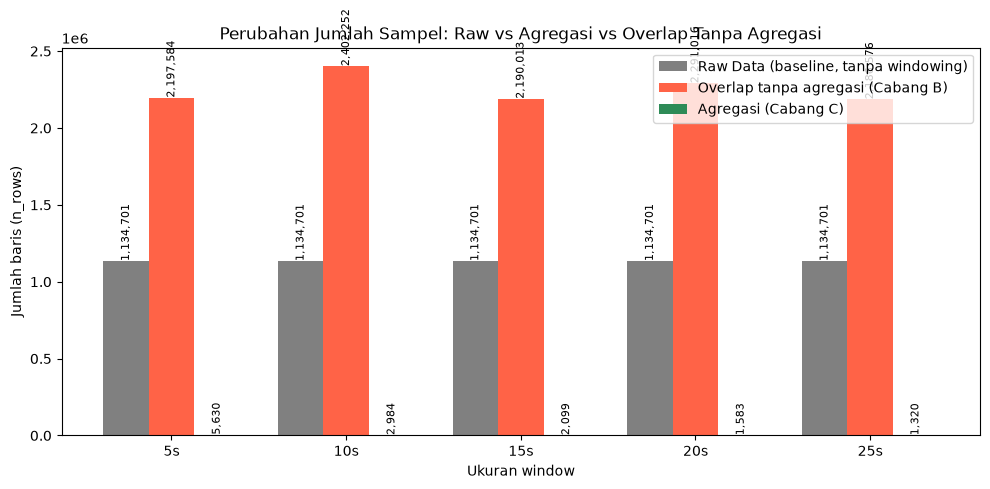

   window_size_sec  raw_no_window  overlap_raw (Cabang B)  aggregated (Cabang C)  overlap_vs_raw_ratio_x  aggregated_vs_raw_ratio_x
0                5        1134701                 2197584                   5630                    1.94                      0.005
1               10        1134701                 2402252                   2984                    2.12                      0.003
2               15        1134701                 2190013                   2099                    1.93                      0.002
3               20        1134701                 2291016                   1583                    2.02                      0.001
4               25        1134701                 2186576                   1320                    1.93                      0.001


In [ ]:
# [FIGURE 2] Grouped bar chart: row count per window size for
# Raw Data (baseline, no windowing -- constant across all window sizes as
# a comparison line), Aggregation (Branch C), and Overlap without aggregation (Branch B).
import matplotlib.pyplot as plt
import numpy as np

window_sizes = CONFIG['window_sizes_sec']
n_raw = candidate_shapes['raw_no_window'][0]

n_overlap = [candidate_shapes[f'overlap_raw_win{w}'][0] for w in window_sizes]
n_aggregated = [candidate_shapes[f'aggregated_win{w}'][0] for w in window_sizes]
n_raw_repeated = [n_raw] * len(window_sizes)

x = np.arange(len(window_sizes))
bar_w = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - bar_w, n_raw_repeated, width=bar_w, label='Raw Data (baseline, no windowing)', color='gray')
ax.bar(x, n_overlap, width=bar_w, label='Overlap without aggregation (Branch B)', color='tomato')
ax.bar(x + bar_w, n_aggregated, width=bar_w, label='Aggregation (Branch C)', color='seagreen')

for xi, v in zip(x - bar_w, n_raw_repeated):
    ax.text(xi, v, f"{v:,}", ha='center', va='bottom', fontsize=8, rotation=90)
for xi, v in zip(x, n_overlap):
    ax.text(xi, v, f"{v:,}", ha='center', va='bottom', fontsize=8, rotation=90)
for xi, v in zip(x + bar_w, n_aggregated):
    ax.text(xi, v, f"{v:,}", ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f"{w}s" for w in window_sizes])
ax.set_xlabel("Window size")
ax.set_ylabel("Row count (n_rows)")
ax.set_title("Sample Count Changes: Raw vs Aggregation vs Overlap Without Aggregation")
ax.legend()
plt.tight_layout()

save_figure(
    fig, "fig02_perubahan_jumlah_sampel_windowing",
    "Grouped bar chart of row counts per window size: raw (baseline) vs overlap without aggregation "
    "(data inflation) vs aggregation (compression, one row per window)."
)
plt.show()

sample_count_table = pd.DataFrame({
    'window_size_sec': window_sizes,
    'raw_no_window': n_raw_repeated,
    'overlap_raw (Cabang B)': n_overlap,
    'aggregated (Cabang C)': n_aggregated,
})
sample_count_table['overlap_vs_raw_ratio_x'] = (sample_count_table['overlap_raw (Cabang B)'] / n_raw).round(2)
sample_count_table['aggregated_vs_raw_ratio_x'] = (sample_count_table['aggregated (Cabang C)'] / n_raw).round(3)
print(df_to_monospace(sample_count_table))

## Stage 5 — Model Definition

Model factories (not instances) — called repeatedly per fold to prevent state leakage across folds, following the `model_factory` pattern in `ble_utils.evaluation.run_lodo`. Hyperparameters/sizes are automatically reduced if `CONFIG['quick_mode']=True` (for fast iteration) — increase them for final numbers.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import lightgbm as lgb

Q = CONFIG['quick_mode']
N_JOBS = CONFIG['n_jobs']
USE_GPU = CONFIG.get('use_gpu', False)

def make_xgb():
    return XGBClassifier(
        n_estimators=100 if Q else 500, max_depth=6 if Q else 8,
        learning_rate=0.3, tree_method='hist', n_jobs=N_JOBS,
        eval_metric='mlogloss', verbosity=0,
        **({'device': 'cuda'} if USE_GPU else {}),
    )

def make_lgbm():
    return lgb.LGBMClassifier(
        n_estimators=100 if Q else 500, num_leaves=31, max_depth=-1,
        learning_rate=0.1, n_jobs=N_JOBS, verbosity=-1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=100 if Q else 500, max_depth=12 if Q else 20,
        class_weight='balanced_subsample', n_jobs=N_JOBS, random_state=RANDOM_STATE,
    )

def make_logreg():
    # linear model -- NOT scale-invariant like the tree models, and can't
    # accept NaN natively (unlike XGBoost/LightGBM/RandomForest) -- so it
    # needs its own impute+scale steps; wrapped in a Pipeline so
    # `evaluate_models`'s `_fit_with_optional_sample_weight` dispatch
    # (Pipeline-aware) handles it.
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, n_jobs=N_JOBS)),
    ])

def make_mlp():
    # sklearn MLPClassifier, not Keras/TensorFlow -- see RAM notes in Stage 0.
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(64,) if Q else (128, 64),
            alpha=1e-3, early_stopping=True, max_iter=100 if Q else 300,
            random_state=RANDOM_STATE,
        )),
    ])

ALL_MODEL_FACTORIES = {
    'xgb': make_xgb, 'lgbm': make_lgbm, 'rf': make_rf,
    'logreg': make_logreg, 'mlp': make_mlp,
}
print("Models defined:", list(ALL_MODEL_FACTORIES.keys()))

Models defined: ['xgb', 'lgbm', 'rf', 'logreg', 'mlp']


## Stage 6 — Windowing Ablation (fixed model = XGBoost, fixed split = LODO)

Compare all 11 candidates (1 raw + 5 overlap + 5 aggregated) using the SAME model and split protocol (fast XGBoost + LODO) to ensure score differences purely reflect the choice of windowing. XGBoost is chosen as the reference model at this stage because it is the fastest to train among the five models — not because it will definitely be the final model (that is determined in Stage 8).

**The winning windowing candidate/size** (highest LODO macro F1) is used as the default dataset for Stage 7 (split ablation) and Stage 8 (model comparison).

In [16]:
NON_FEATURE_COLS = ['window_id', 'window_position', 'window_size', 'group_window_count']

window_ablation_rows = []

for name, path in candidate_paths.items():
    with track_ram(f"ablation: {name}"):
        cand_df = pd.read_parquet(path)
        report = evaluate_models(
            cand_df, {'xgb': make_xgb}, protocol='lodo',
            day_col='year_month_day', target_col='room', group_col='room_group_id',
            drop_cols=NON_FEATURE_COLS,
            class_weight_max=CONFIG['class_weight_max'], verbose=False,
        )
        summ = summarize_evaluate_models(report)
        if not summ.empty:
            row = summ.iloc[0].to_dict()
            row['candidate'] = name
            row['n_rows'] = len(cand_df)
            window_ablation_rows.append(row)
        free(cand_df); cand_df = None

window_ablation_report = pd.DataFrame(window_ablation_rows).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
window_ablation_report.to_csv(f"{CONFIG['models_dir']}/window_ablation_report.csv", index=False)

WINNING_CANDIDATE = window_ablation_report.iloc[0]['candidate']
print(f"\n>>> WINDOWING WINNER: {WINNING_CANDIDATE} "
      f"(macro_f1={window_ablation_report.iloc[0]['macro_f1_mean']:.4f})")
window_ablation_report[['candidate', 'n_rows', 'macro_f1_mean', 'macro_f1_std', 'mean_train_seconds']]

[ablation: raw_no_window] 825.7s, RAM 1436 -> 1494 MB (delta +58 MB)
[ablation: overlap_raw_win5] 1597.6s, RAM 1494 -> 2642 MB (delta +1148 MB)
[ablation: overlap_raw_win10] 1834.8s, RAM 2642 -> 2746 MB (delta +103 MB)
[ablation: overlap_raw_win15] 1533.7s, RAM 2746 -> 1484 MB (delta -1263 MB)
[ablation: overlap_raw_win20] 1697.4s, RAM 1484 -> 2111 MB (delta +627 MB)
[ablation: overlap_raw_win25] 1579.4s, RAM 2111 -> 2163 MB (delta +51 MB)
[ablation: aggregated_win5] 75.9s, RAM 2163 -> 1828 MB (delta -335 MB)
[ablation: aggregated_win10] 58.1s, RAM 1828 -> 427 MB (delta -1401 MB)
[ablation: aggregated_win15] 46.4s, RAM 427 -> 440 MB (delta +13 MB)
[ablation: aggregated_win20] 39.8s, RAM 440 -> 434 MB (delta -6 MB)
[ablation: aggregated_win25] 37.3s, RAM 434 -> 446 MB (delta +13 MB)

>>> WINDOWING WINNER: aggregated_win20 (macro_f1=0.3369)


,candidate,n_rows,macro_f1_mean,macro_f1_std,mean_train_seconds
0,aggregated_win20,1583,0.336898,0.051846,9.504888
1,aggregated_win25,1320,0.324304,0.073665,8.853794
2,aggregated_win15,2099,0.274911,0.096596,11.142281
3,aggregated_win10,2984,0.270374,0.041893,14.044558
4,aggregated_win5,5630,0.247773,0.040802,18.447930
5,overlap_raw_win5,2197584,0.125193,0.070764,392.160775
6,overlap_raw_win20,2291016,0.094187,0.032940,416.731923
7,overlap_raw_win25,2186576,0.090981,0.044902,387.157217
8,overlap_raw_win15,2190013,0.090891,0.029738,376.930000
9,overlap_raw_win10,2402252,0.087787,0.052718,450.456921


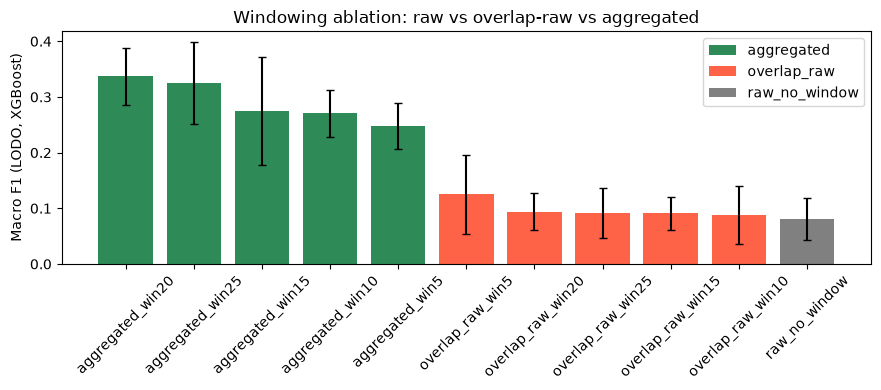

In [17]:
# quick visual: macro F1 by candidate, raw baseline vs overlap-raw vs aggregated
import matplotlib.pyplot as plt

plot_df = window_ablation_report.copy()
plot_df['family'] = plot_df['candidate'].apply(
    lambda n: 'raw_no_window' if n == 'raw_no_window' else ('overlap_raw' if n.startswith('overlap_raw') else 'aggregated')
)
fig, ax = plt.subplots(figsize=(9, 4))
colors = {'raw_no_window': 'gray', 'overlap_raw': 'tomato', 'aggregated': 'seagreen'}
for fam, sub in plot_df.groupby('family'):
    ax.bar(sub['candidate'], sub['macro_f1_mean'], yerr=sub['macro_f1_std'], color=colors.get(fam), label=fam, capsize=3)
ax.set_ylabel('Macro F1 (LODO, XGBoost)')
ax.set_title('Windowing ablation: raw vs overlap-raw vs aggregated')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### 6.1 — [FIGURE] Window Size Sensitivity on Performance (Macro F1)

A line chart featuring two intersecting lines (Aggregation vs Overlap without aggregation) across window sizes of `{5, 10, 15, 20, 25}` seconds, to justify the selection of the best empirical window size and observe which is more stable.

[FIGURE SAVED] fig03_sensitivitas_window_size_macro_f1
  -> outputs\figures\fig03_sensitivitas_window_size_macro_f1.png
  -> outputs\figures\fig03_sensitivitas_window_size_macro_f1.pdf
  -> outputs\figures\fig03_sensitivitas_window_size_macro_f1.svg


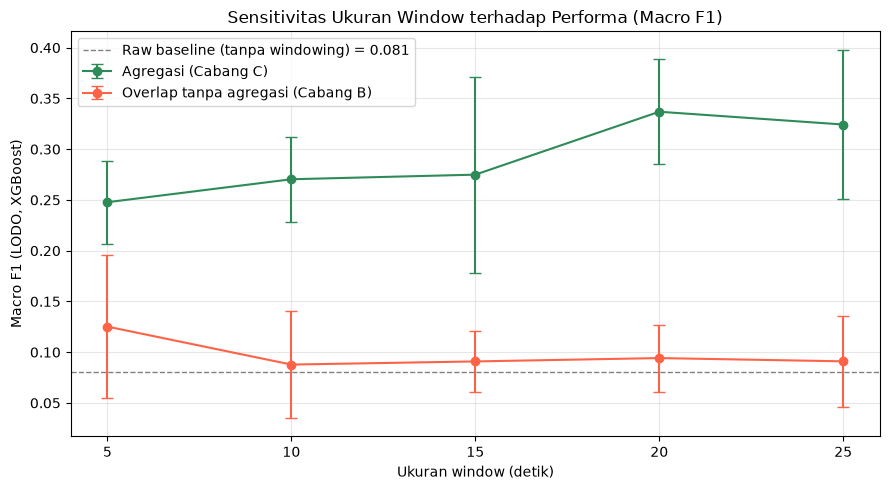

        family  window_sec  macro_f1_mean  macro_f1_std
0   aggregated           5       0.247773      0.040802
1   aggregated          10       0.270374      0.041893
2   aggregated          15       0.274911      0.096596
3   aggregated          20       0.336898      0.051846
4   aggregated          25       0.324304      0.073665
5  overlap_raw           5       0.125193      0.070764
6  overlap_raw          10       0.087787      0.052718
7  overlap_raw          15       0.090891      0.029738
8  overlap_raw          20       0.094187      0.032940
9  overlap_raw          25       0.090981      0.044902


In [ ]:
# [FIGURE 3] Line chart: Macro F1 (LODO, XGBoost) vs window size, two lines
# (Aggregation vs Overlap without aggregation) -- using window_ablation_report (Stage 6).
import matplotlib.pyplot as plt
import re

def _parse_window_family(name):
    m = re.match(r'^(aggregated|overlap_raw)_win(\d+)$', name)
    if not m:
        return None, None
    return m.group(1), int(m.group(2))

sens_rows = []
for _, r in window_ablation_report.iterrows():
    fam, w = _parse_window_family(r['candidate'])
    if fam is None:
        continue
    sens_rows.append({'family': fam, 'window_sec': w, 'macro_f1_mean': r['macro_f1_mean'], 'macro_f1_std': r['macro_f1_std']})
sensitivity_df = pd.DataFrame(sens_rows).sort_values(['family', 'window_sec']).reset_index(drop=True)

raw_baseline_f1 = window_ablation_report.loc[window_ablation_report['candidate'] == 'raw_no_window', 'macro_f1_mean']
raw_baseline_f1 = float(raw_baseline_f1.iloc[0]) if not raw_baseline_f1.empty else None

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'aggregated': 'seagreen', 'overlap_raw': 'tomato'}
labels = {'aggregated': 'Aggregation (Branch C)', 'overlap_raw': 'Overlap without aggregation (Branch B)'}
for fam, sub in sensitivity_df.groupby('family'):
    ax.errorbar(sub['window_sec'], sub['macro_f1_mean'], yerr=sub['macro_f1_std'],
                marker='o', capsize=4, label=labels.get(fam, fam), color=colors.get(fam))

if raw_baseline_f1 is not None:
    ax.axhline(raw_baseline_f1, linestyle='--', color='gray', linewidth=1,
               label=f'Raw baseline (no windowing) = {raw_baseline_f1:.3f}')

ax.set_xlabel("Window size (seconds)")
ax.set_ylabel("Macro F1 (LODO, XGBoost)")
ax.set_title("Window Size Sensitivity on Performance (Macro F1)")
ax.set_xticks(sorted(sensitivity_df['window_sec'].unique()))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

save_figure(
    fig, "fig03_sensitivitas_window_size_macro_f1",
    "Line chart of Macro F1 (LODO, XGBoost) vs window size, comparing the aggregation branch vs "
    "overlap without aggregation, with a dashed line representing the raw baseline (no windowing)."
)
plt.show()

print(df_to_monospace(sensitivity_df))

## Stage 7 — Split Protocol Ablation (fixed windowing = Stage 6 winner)

Compare LODO vs. Repeated Stratified Group K-Fold vs. Stratified random split, keeping the model fixed to XGBoost, on the winning windowing dataset. This directly measures the **score inflation** caused by inter-split data leakage. We expect `stratified_random > stratified_group_kfold > lodo` here, and the magnitude of this difference (not just the ranking) constitutes the reported finding.

In [ ]:
winning_df = pd.read_parquet(candidate_paths[WINNING_CANDIDATE])
winning_df = winning_df.drop(columns=[c for c in winning_df.columns if c.startswith('Unnamed')], errors='ignore')

import re
winning_df.columns = [re.sub(r'[^0-9a-zA-Z_]+', '_', str(c)) for c in winning_df.columns]

split_ablation_reports = []
for protocol in ['lodo', 'stratified_group_kfold', 'stratified_random']:
    with track_ram(f"split ablation: {protocol}"):
        rep = evaluate_models(
            winning_df, {'xgb': make_xgb}, protocol=protocol,
            day_col='year_month_day', target_col='room', group_col='room_group_id',
            drop_cols=NON_FEATURE_COLS,
            n_splits=CONFIG['rsgkf_n_splits'], n_repeats=CONFIG['rsgkf_n_repeats'],
            random_state=RANDOM_STATE, class_weight_max=CONFIG['class_weight_max'],
            include_ensemble=False, verbose=False,
        )
        split_ablation_reports.append(rep)

split_ablation_report = pd.concat(split_ablation_reports, ignore_index=True)
split_ablation_summary = summarize_evaluate_models(split_ablation_report)
split_ablation_summary.to_csv(f"{CONFIG['models_dir']}/split_protocol_ablation_report.csv", index=False)

inflation = split_ablation_summary.set_index('protocol')['macro_f1_mean']
print("Macro F1 by split protocol (same model, same windowing):")
print(inflation)
if 'lodo' in inflation.index and 'stratified_random' in inflation.index:
    print(f"\nstratified_random vs lodo inflation: "
          f"{inflation['stratified_random'] - inflation['lodo']:+.4f} macro F1")
if 'lodo' in inflation.index and 'stratified_group_kfold' in inflation.index:
    print(f"stratified_group_kfold vs lodo inflation: "
          f"{inflation['stratified_group_kfold'] - inflation['lodo']:+.4f} macro F1")
split_ablation_summary

[split ablation: lodo] 40.2s, RAM 508 -> 527 MB (delta +18 MB)
[split ablation: stratified_group_kfold] 314.8s, RAM 527 -> 580 MB (delta +54 MB)
[split ablation: stratified_random] 53.8s, RAM 580 -> 591 MB (delta +11 MB)
Macro F1 by split protocol (same model, same windowing):
protocol
stratified_random         0.672181
stratified_group_kfold    0.415403
lodo                      0.341502
Name: macro_f1_mean, dtype: float64

Inflasi stratified_random vs lodo: +0.3307 macro F1
Inflasi stratified_group_kfold vs lodo: +0.0739 macro F1


,protocol,model,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,accuracy_mean,accuracy_std,mean_train_seconds,n_folds_scored
0,stratified_random,xgb,0.672181,0.067153,0.851594,0.021186,0.855331,0.019308,10.312340,5
1,stratified_group_kfold,xgb,0.415403,0.061473,0.728541,0.056319,0.728621,0.056036,10.035754,30
2,lodo,xgb,0.341502,0.052247,0.658117,0.122552,0.646079,0.127857,9.610765,4


### 7.1 — [FIGURE] Stratified Random Split vs LODO CV (Main Highlight)

A side-by-side bar chart directly comparing the Macro F1 scores of the exact same model (XGBoost, windowing = Stage 6 winner) under different split protocols. The `stratified_random` split is expected to yield artificially higher scores (indicating *data leakage* or pseudo-overfitting), whereas `lodo` will result in lower scores that more accurately reflect the model's robustness in real-world scenarios — this score inflation constitutes the core reported finding.

[FIGURE SAVED] fig04_perbandingan_split_protocol_stratified_vs_lodo
  -> outputs\figures\fig04_perbandingan_split_protocol_stratified_vs_lodo.png
  -> outputs\figures\fig04_perbandingan_split_protocol_stratified_vs_lodo.pdf
  -> outputs\figures\fig04_perbandingan_split_protocol_stratified_vs_lodo.svg


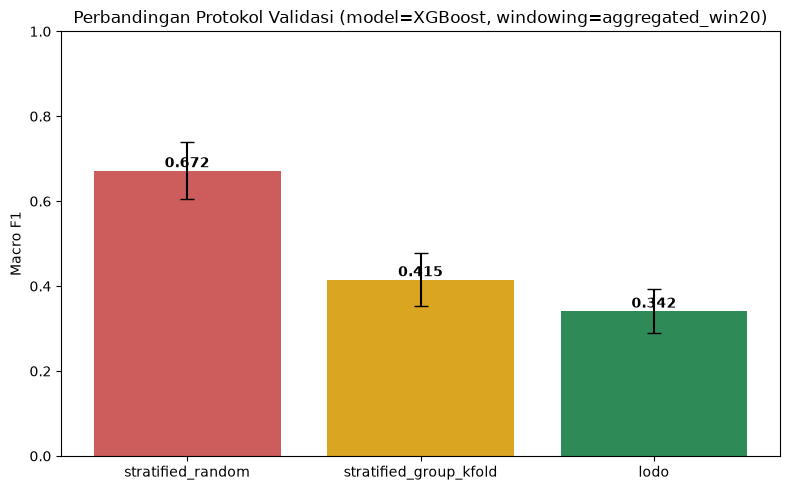

Inflasi Macro F1 (stratified_random - lodo): +0.3307
                 protocol model  macro_f1_mean  macro_f1_std  weighted_f1_mean  weighted_f1_std  accuracy_mean  accuracy_std  mean_train_seconds  n_folds_scored
0       stratified_random   xgb       0.672181      0.067153          0.851594         0.021186       0.855331      0.019308           10.312340               5
1  stratified_group_kfold   xgb       0.415403      0.061473          0.728541         0.056319       0.728621      0.056036           10.035754              30
2                    lodo   xgb       0.341502      0.052247          0.658117         0.122552       0.646079      0.127857            9.610765               4


In [ ]:
# [FIGURE 4] Side-by-side bar chart: Macro F1 per split protocol (fixed model &
# windowing) -- using split_ablation_summary (Stage 7). Key highlight: lodo vs
# stratified_random (data leakage / pseudo-overfitting vs. realistic evaluation).
import matplotlib.pyplot as plt

protocol_order = ['stratified_random', 'stratified_group_kfold', 'lodo']
plot_summary = split_ablation_summary.set_index('protocol').reindex(
    [p for p in protocol_order if p in split_ablation_summary['protocol'].values]
).reset_index()

colors_map = {'stratified_random': 'indianred', 'stratified_group_kfold': 'goldenrod', 'lodo': 'seagreen'}
bar_colors = [colors_map.get(p, 'steelblue') for p in plot_summary['protocol']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_summary['protocol'], plot_summary['macro_f1_mean'],
              yerr=plot_summary['macro_f1_std'], color=bar_colors, capsize=5)
for bar, val in zip(bars, plot_summary['macro_f1_mean']):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.3f}", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel("Macro F1")
ax.set_title(f"Validation Protocol Comparison (model=XGBoost, windowing={WINNING_CANDIDATE})")
ax.set_ylim(0, max(1.0, plot_summary['macro_f1_mean'].max() * 1.2))
plt.tight_layout()

save_figure(
    fig, "fig04_perbandingan_split_protocol_stratified_vs_lodo",
    "Side-by-side bar chart of Macro F1 per split protocol (stratified_random vs "
    "stratified_group_kfold vs lodo), identical model & windowing -- highlighting score inflation due to data leakage."
)
plt.show()

if 'lodo' in plot_summary['protocol'].values and 'stratified_random' in plot_summary['protocol'].values:
    f1_lodo = plot_summary.loc[plot_summary['protocol'] == 'lodo', 'macro_f1_mean'].iloc[0]
    f1_stratrandom = plot_summary.loc[plot_summary['protocol'] == 'stratified_random', 'macro_f1_mean'].iloc[0]
    print(f"Macro F1 Inflation (stratified_random - lodo): {f1_stratrandom - f1_lodo:+.4f}")

print(df_to_monospace(plot_summary))

## Stage 8 — Model Comparison (windowing = Stage 6 winner, primary split = LODO)

Five models (XGBoost, LightGBM, RandomForest, Logistic Regression, MLP) plus a **soft-vote ensemble** (averaging the predicted probabilities of all models) are evaluated using the most rigorous and realistic protocol (LODO) on the winning windowing dataset. This constitutes the **main results table** for the paper.

In [ ]:
with track_ram("model comparison (LODO)"):
    model_comparison_report = evaluate_models(
        winning_df, ALL_MODEL_FACTORIES, protocol='lodo',
        day_col='year_month_day', target_col='room', group_col='room_group_id',
        drop_cols=NON_FEATURE_COLS,
        class_weight_max=CONFIG['class_weight_max'], return_overfit_gap=True, verbose=True,
    )

model_comparison_summary = summarize_evaluate_models(model_comparison_report)
model_comparison_report.to_csv(f"{CONFIG['models_dir']}/model_comparison_report_lodo.csv", index=False)
model_comparison_summary.to_csv(f"{CONFIG['models_dir']}/model_comparison_summary_lodo.csv", index=False)

BEST_MODEL_NAME = model_comparison_summary.iloc[0]['model']
print(f"\n>>> BEST MODEL (LODO, windowing={WINNING_CANDIDATE}): {BEST_MODEL_NAME} "
      f"(macro_f1={model_comparison_summary.iloc[0]['macro_f1_mean']:.4f})")
model_comparison_summary

lodo_2023-04-10: best=xgb macro_f1=0.3265 (train=1,137, val=446, dropped_unseen=0)
lodo_2023-04-11: best=ensemble_soft_vote(xgb+lgbm+rf+logreg+mlp) macro_f1=0.5644 (train=1,112, val=471, dropped_unseen=0)
lodo_2023-04-12: best=mlp macro_f1=0.4449 (train=1,106, val=469, dropped_unseen=8)
lodo_2023-04-13: best=rf macro_f1=0.3382 (train=1,394, val=186, dropped_unseen=3)
[model comparison (LODO)] 76.3s, RAM 480 -> 527 MB (delta +47 MB)

>>> BEST MODEL (LODO, windowing=aggregated_win20): ensemble_soft_vote(xgb+lgbm+rf+logreg+mlp) (macro_f1=0.4050)


,protocol,model,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,accuracy_mean,accuracy_std,mean_train_seconds,n_folds_scored
0,lodo,ensemble_soft_vote(xgb+lgbm+rf+logreg+mlp),0.404961,0.120545,0.694877,0.097288,0.686786,0.092753,NaN,4
1,lodo,rf,0.384331,0.089029,0.635527,0.082467,0.622866,0.068553,0.819704,4
2,lodo,logreg,0.353315,0.113266,0.593281,0.110399,0.581186,0.109587,1.643355,4
3,lodo,lgbm,0.344654,0.059998,0.685603,0.088321,0.676599,0.091074,4.647837,4
4,lodo,xgb,0.341502,0.052247,0.658117,0.122552,0.646079,0.127857,9.759209,4
5,lodo,mlp,0.326302,0.082318,0.601892,0.064190,0.595158,0.058998,1.453325,4


### 8.1 — [FIGURE] Per-Class F1 Score & Confusion Matrix (LODO)

Two visualizations for model evaluation and minority class analysis:
1. **Per-Class F1 Score** (diverging bar chart) — answers "why does Macro F1 drop so low?": majority classes typically achieve high F1 scores, but minority classes (e.g., rooms 502/505/510) often collapse to F1=0.
2. **Confusion Matrix** (heatmap) — model error patterns (error analysis): whether the model frequently misclassifies `hallway` as patient rooms, etc. This demonstrates that model errors are non-random and instead stem from spatial ambiguity between adjacent rooms.

Both are computed from out-of-fold LODO predictions pooled across all held-out days, using the best-performing model from Stage 8 (falling back to XGBoost if the best model is an ensemble, allowing per-fold refitting).

In [ ]:
# [Preparation for FIGURES 5 & 6] Re-run LODO (using the best model from Stage 8,
# or XGBoost if the best model is 'ensemble' -- since ensembles cannot be
# refitted directly via a single model_factory), collecting (y_true, y_pred) in
# original ROOM NAMES (not just encoded indices) pooled across all held-out
# days, ensuring per-class F1 & confusion matrix reflect overall LODO performance
# (rather than a single fold).
from sklearn.metrics import confusion_matrix as _confusion_matrix, classification_report as _classification_report
from sklearn.preprocessing import LabelEncoder as _LabelEncoderCM

CM_MODEL_NAME = BEST_MODEL_NAME if BEST_MODEL_NAME in ALL_MODEL_FACTORIES else 'xgb'
_cm_model_factory = ALL_MODEL_FACTORIES[CM_MODEL_NAME]

feature_cols_cm = [c for c in winning_df.columns if c not in ('year_month_day', 'room', 'room_group_id', *NON_FEATURE_COLS)]
all_rooms_sorted = sorted(winning_df['room'].unique())

y_true_all_lodo, y_pred_all_lodo = [], []
with track_ram(f"pooled LODO predictions ({CM_MODEL_NAME}) for per-class F1 & confusion matrix"):
    for fold_name, train_idx, val_idx in iterate_splits(winning_df, 'lodo', day_col='year_month_day', target_col='room'):
        train_fold = winning_df.loc[train_idx]
        val_fold = winning_df.loc[val_idx]

        le_fold = _LabelEncoderCM()
        y_train_enc = le_fold.fit_transform(train_fold['room'])
        known_classes = set(le_fold.classes_)

        val_known_mask = val_fold['room'].isin(known_classes)
        val_fold_scored = val_fold[val_known_mask]
        if val_fold_scored.empty:
            continue

        model = _cm_model_factory()
        model.fit(train_fold[feature_cols_cm], y_train_enc)
        y_pred_enc = model.predict(val_fold_scored[feature_cols_cm])
        y_pred_rooms = le_fold.inverse_transform(y_pred_enc)

        y_true_all_lodo.extend(val_fold_scored['room'].tolist())
        y_pred_all_lodo.extend(list(y_pred_rooms))

print(f"Model used for confusion matrix / per-class F1: {CM_MODEL_NAME}")
print(f"Total scored rows (pooled across all held-out days): {len(y_true_all_lodo):,}")

lodo_confusion_matrix = _confusion_matrix(y_true_all_lodo, y_pred_all_lodo, labels=all_rooms_sorted)
lodo_confusion_df = pd.DataFrame(lodo_confusion_matrix, index=all_rooms_sorted, columns=all_rooms_sorted)

_report_dict = _classification_report(
    y_true_all_lodo, y_pred_all_lodo, labels=all_rooms_sorted, output_dict=True, zero_division=0,
)
per_class_f1_lodo = (
    pd.DataFrame(_report_dict).T.loc[all_rooms_sorted, ['precision', 'recall', 'f1-score', 'support']]
    .sort_values('f1-score')
)
per_class_f1_lodo.to_csv(f"{CONFIG['models_dir']}/per_class_f1_lodo_{CM_MODEL_NAME}.csv")
lodo_confusion_df.to_csv(f"{CONFIG['models_dir']}/confusion_matrix_lodo_{CM_MODEL_NAME}.csv")

print("\nPer-class F1 (LODO, pooled, sorted from weakest):")
print(df_to_monospace(per_class_f1_lodo))

[FIGURE SAVED] fig05_per_class_f1_lodo
  -> outputs\figures\fig05_per_class_f1_lodo.png
  -> outputs\figures\fig05_per_class_f1_lodo.pdf
  -> outputs\figures\fig05_per_class_f1_lodo.svg


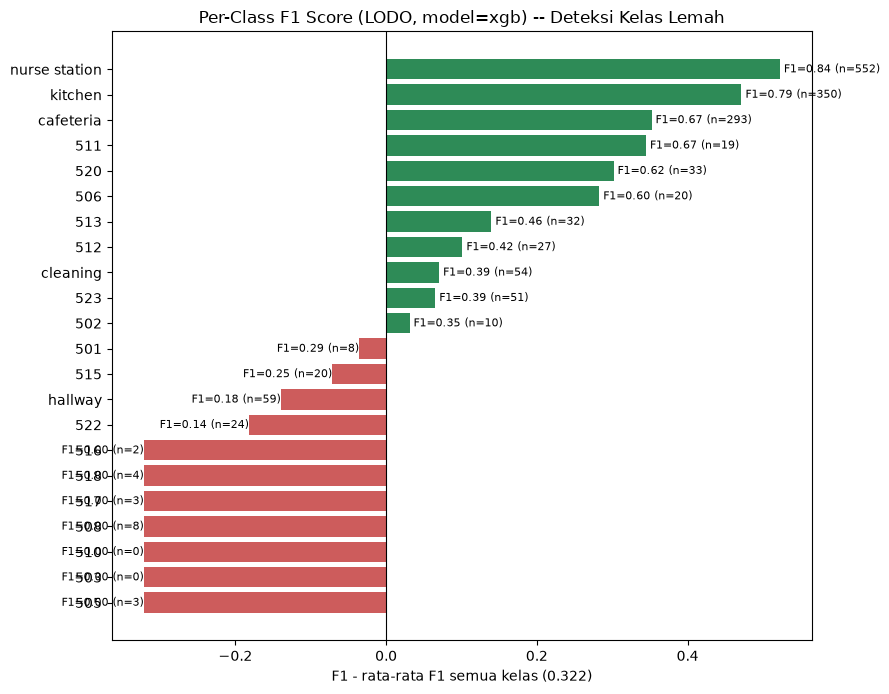

In [ ]:
# [FIGURE 5] Diverging bar chart: Per-Class F1 Score (LODO, pooled) -- diverging
# from the mean Macro F1; red = below average (classes dragging down
# Macro F1), green = above average.
import matplotlib.pyplot as plt

plot_pcf1 = per_class_f1_lodo.copy().sort_values('f1-score')
mean_f1 = plot_pcf1['f1-score'].mean()
diverge = plot_pcf1['f1-score'] - mean_f1
colors_div = ['indianred' if v < 0 else 'seagreen' for v in diverge]

fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(plot_pcf1))))
ax.barh(plot_pcf1.index.astype(str), diverge.values, color=colors_div)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f"F1 - Average F1 Across All Classes ({mean_f1:.3f})")
ax.set_title(f"Per-Class F1 Score (LODO, model={CM_MODEL_NAME}) -- Weak Class Detection")

for y, (v, support) in enumerate(zip(plot_pcf1['f1-score'], plot_pcf1['support'])):
    ax.text(diverge.iloc[y], y, f" F1={v:.2f} (n={int(support)})",
            va='center', ha='left' if diverge.iloc[y] >= 0 else 'right', fontsize=8)

plt.tight_layout()

save_figure(
    fig, "fig05_per_class_f1_lodo",
    f"Diverging bar chart of per-class F1 (LODO, pooled, model={CM_MODEL_NAME}), diverging from mean; "
    "showing minority classes with F1 near 0 vs majority classes with high F1."
)
plt.show()

[FIGURE SAVED] fig06_confusion_matrix_lodo
  -> outputs\figures\fig06_confusion_matrix_lodo.png
  -> outputs\figures\fig06_confusion_matrix_lodo.pdf
  -> outputs\figures\fig06_confusion_matrix_lodo.svg


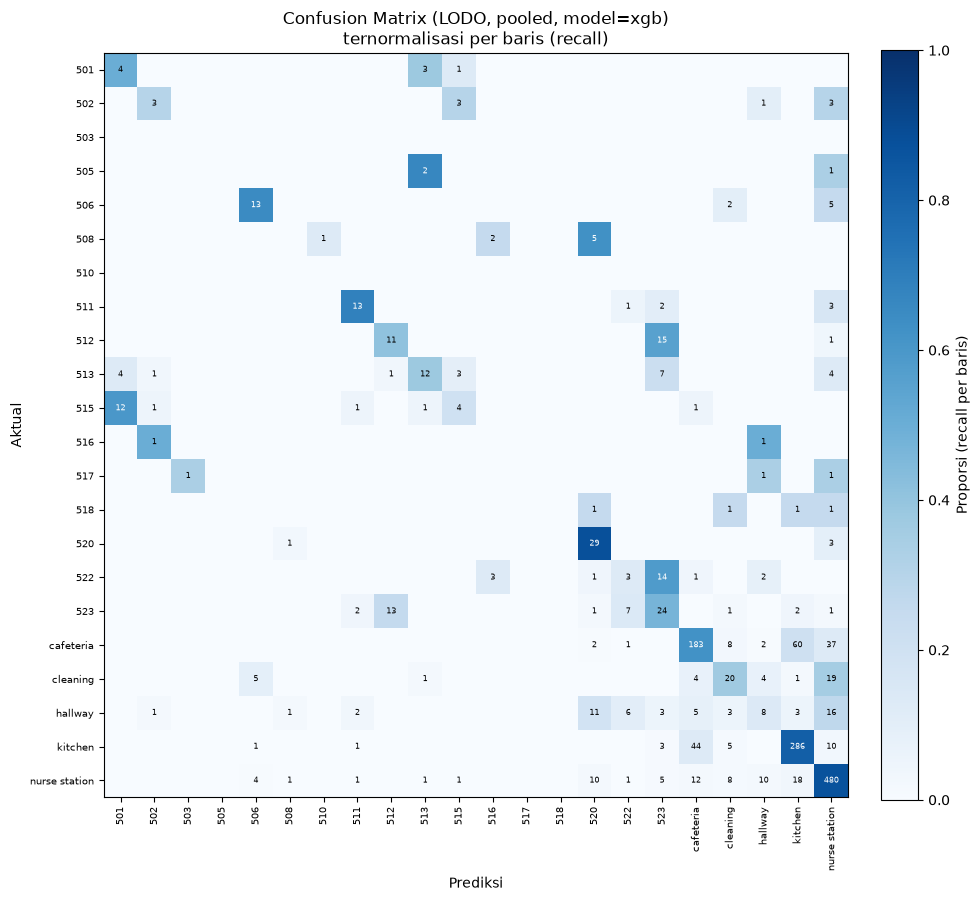

In [ ]:
# [FIGURE 6] Confusion Matrix heatmap (LODO, pooled across all held-out days) --
# normalized per row (recall per true class) so that error patterns (e.g.,
# hallway frequently misclassified as an adjacent patient room) are clearly visible
# despite heavy class imbalance.
import matplotlib.pyplot as plt
import numpy as np

cm_raw = lodo_confusion_df.values.astype(float)
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, out=np.zeros_like(cm_raw), where=row_sums != 0)

n_labels = len(all_rooms_sorted)
fig, ax = plt.subplots(figsize=(max(8, 0.45 * n_labels), max(7, 0.45 * n_labels)))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(n_labels))
ax.set_yticks(range(n_labels))
ax.set_xticklabels(all_rooms_sorted, rotation=90, fontsize=7)
ax.set_yticklabels(all_rooms_sorted, fontsize=7)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (LODO, pooled, model={CM_MODEL_NAME})\nRow-normalized (Recall)")

# Annotate numbers only if grid is manageable to keep it legible
if n_labels <= 30:
    for i in range(n_labels):
        for j in range(n_labels):
            if cm_raw[i, j] > 0:
                ax.text(j, i, int(cm_raw[i, j]), ha='center', va='center',
                        fontsize=6, color='white' if cm_norm[i, j] > 0.5 else 'black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Proportion (Row Recall)')
plt.tight_layout()

save_figure(
    fig, "fig06_confusion_matrix_lodo",
    f"Confusion matrix heatmap (LODO, pooled, model={CM_MODEL_NAME}), row-normalized; "
    "showing model error patterns across spatially adjacent rooms."
)
plt.show()

### (Optional, Compute-Intensive) Full Matrix: All Models x All Windowing Candidates x All Split Protocols

Enabled via `CONFIG['run_full_matrix']=True`. This can be computationally intensive and time-consuming (11 windowing candidates x 5 models x 3 protocols) — run it overnight if you need the exhaustive table for the paper, or leave it set to `False` for fast daily iterations.

In [ ]:
full_matrix_report = None

if CONFIG['run_full_matrix']:
    full_matrix_rows = []
    for name, path in candidate_paths.items():
        cand_df = pd.read_parquet(path)
        cand_df = cand_df.drop(columns=[c for c in cand_df.columns if c.startswith('Unnamed')], errors='ignore')
        cand_df.columns = [re.sub(r'[^0-9a-zA-Z_]+', '_', str(c)) for c in cand_df.columns]
        for protocol in ['lodo', 'stratified_group_kfold', 'stratified_random']:
            with track_ram(f"full matrix: {name} x {protocol}"):
                rep = evaluate_models(
                    cand_df, ALL_MODEL_FACTORIES, protocol=protocol,
                    day_col='year_month_day', target_col='room', group_col='room_group_id',
                    drop_cols=NON_FEATURE_COLS,
                    n_splits=CONFIG['rsgkf_n_splits'], n_repeats=CONFIG['rsgkf_n_repeats'],
                    class_weight_max=CONFIG['class_weight_max'], verbose=False,
                )
                rep['candidate'] = name
                full_matrix_rows.append(rep)
        free(cand_df); cand_df = None

    full_matrix_report = pd.concat(full_matrix_rows, ignore_index=True)
    full_matrix_summary = full_matrix_report.groupby(['candidate', 'protocol', 'model']).agg(
        macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
    ).reset_index().sort_values('macro_f1_mean', ascending=False)
    full_matrix_summary.to_csv(f"{CONFIG['models_dir']}/full_matrix_summary.csv", index=False)
    display(full_matrix_summary.head(20))
else:
    print("run_full_matrix=False -- skipped full matrix (see Stages 6/7/8 for summarized results).")

## Stage 9 — Sanity Check: Overfitting, Leakage, Distribution, Feature Importance

Several verification checks that were not explicitly performed in the original notebooks (see teammate notes in Sections 6.9/7.35 — "never checked, do not assume the model is automatically safe").

### 9.1 — Overfitting: train-F1 vs val-F1 gap per model

`return_overfit_gap=True` di Tahap 8 sudah menghitung `train_macro_f1` dan
`overfit_gap` per fold. Gap besar & konsisten = model menghafal training fold,
bukan generalisasi — sinyal untuk mengecilkan model (kurangi `n_estimators`/
`max_depth`, naikkan regularisasi) sebelum mempercayai skor val-nya.

In [32]:
overfit_summary = model_comparison_report.groupby('model').agg(
    train_macro_f1_mean=('train_macro_f1', 'mean'),
    val_macro_f1_mean=('macro_f1', 'mean'),
    overfit_gap_mean=('overfit_gap', 'mean'),
    overfit_gap_std=('overfit_gap', 'std'),
).sort_values('overfit_gap_mean', ascending=False).reset_index()
overfit_summary

,model,train_macro_f1_mean,val_macro_f1_mean,overfit_gap_mean,overfit_gap_std
0,xgb,1.000000,0.341502,0.658498,0.052247
1,lgbm,1.000000,0.344654,0.655346,0.059998
2,logreg,0.964524,0.353315,0.611209,0.113280
3,rf,0.964819,0.384331,0.580488,0.094150
4,mlp,0.853095,0.326302,0.526793,0.129955
5,ensemble_soft_vote(xgb+lgbm+rf+logreg+mlp),NaN,0.404961,NaN,NaN


### 9.2 — Leakage Check: Ensure No Overlapping `year_month_day` Between Train & Val (LODO)

In [33]:
leakage_ok = True
for fold_name, train_idx, val_idx in iterate_splits(winning_df, 'lodo', day_col='year_month_day', target_col='room'):
    train_days = set(winning_df.loc[train_idx, 'year_month_day'])
    val_days = set(winning_df.loc[val_idx, 'year_month_day'])
    if train_days & val_days:
        leakage_ok = False
        print(f"LEAKAGE at {fold_name}: overlapping days {train_days & val_days}")
print("LODO day-level leakage check:", "OK (no overlap)" if leakage_ok else "FAILED -- see above")

LODO day-level leakage check: OK (no overlap)


### 9.3 — Class Distribution: Before vs. After Windowing (Winning Candidate)

In [34]:
before_dist = pd.read_parquet(f"{CONFIG['processed_dir']}/features_normalized.parquet")['room'].value_counts(normalize=True).sort_index()
after_dist = winning_df['room'].value_counts(normalize=True).sort_index()
dist_compare = pd.DataFrame({'before_windowing': before_dist, 'after_windowing': after_dist}).fillna(0.0)
dist_compare['abs_diff'] = (dist_compare['before_windowing'] - dist_compare['after_windowing']).abs()
dist_compare.sort_values('abs_diff', ascending=False).head(10)

,before_windowing,after_windowing,abs_diff
room,,,
nurse station,0.484576,0.348705,0.135871
kitchen,0.149756,0.221099,0.071343
hallway,0.060126,0.037271,0.022855
cleaning,0.018580,0.034112,0.015532
520,0.009224,0.020846,0.011623
515,0.003726,0.012634,0.008908
512,0.008291,0.017056,0.008765
522,0.007928,0.015161,0.007233
cafeteria,0.178120,0.185092,0.006972


### 9.4 — Unseen-Class Report (LODO) & Feature Importance (XGBoost, Refit on Entire Dataset)

In [35]:
_lodo_rows = []
for fold_name, train_idx, val_idx in iterate_splits(winning_df, 'lodo', day_col='year_month_day', target_col='room'):
    train_rooms = set(winning_df.loc[train_idx, 'room'])
    val_rooms = set(winning_df.loc[val_idx, 'room'])
    _lodo_rows.append({'held_out_day': fold_name.replace('lodo_', ''), 'unseen_classes': sorted(val_rooms - train_rooms)})
unseen_df = pd.DataFrame(_lodo_rows)
unseen_summary = summarize_unseen_classes(unseen_df, n_total_days=len(unseen_df))
unseen_summary

,room,n_folds_unseen,n_folds_total
0,503,1,4
1,510,1,4


In [ ]:
feature_cols_final = [c for c in winning_df.columns if c not in ('year_month_day', 'room', 'room_group_id', *NON_FEATURE_COLS)]

from sklearn.preprocessing import LabelEncoder as _LabelEncoder

_xgb_full = make_xgb()
_le_full = _LabelEncoder()
_y_full = _le_full.fit_transform(winning_df['room'])
_xgb_full.fit(winning_df[feature_cols_final], _y_full)

importances = pd.Series(_xgb_full.feature_importances_, index=feature_cols_final).sort_values(ascending=False)
print("Top 20 most contributing features (XGBoost gain-based importance, full data):")
importances.head(20)

Top 20 fitur paling berkontribusi (XGBoost gain-based importance, full data):


RSSI_2_rolling_mean_mean     0.173687
RSSI_23_is_strong_mean       0.122727
RSSI_22_mean                 0.102971
RSSI_17_std                  0.042434
RSSI_21_mean                 0.039706
RSSI_16_rolling_std_std      0.033696
RSSI_8_is_strong_mean        0.028461
RSSI_13_is_strong_mean       0.024532
RSSI_12_rolling_std_std      0.021927
RSSI_20_max                  0.020325
RSSI_14_rolling_mean_mean    0.019289
RSSI_16_rolling_mean_mean    0.017506
RSSI_9_is_strong_mean        0.013233
RSSI_23_rolling_mean_mean    0.011993
RSSI_21_is_strong_mean       0.011453
RSSI_15_rolling_mean_mean    0.010984
RSSI_5_is_strong_std         0.010970
RSSI_11_squared_std          0.010165
RSSI_19_max                  0.009022
RSSI_8_squared_mean          0.008207
dtype: float32

### 9.5 — RAM & Execution Time: Summary

In [ ]:
ram_now = current_ram_usage_mb()
print(f"Current process RAM usage: {ram_now:.0f} MB" if ram_now is not None else "psutil is not installed -- run `pip install psutil` to view this.")
print("\nFile sizes on disk (processed/):")
for f in sorted(Path(CONFIG['processed_dir']).glob('*.parquet')):
    print(f"  {f.name}: {f.stat().st_size / (1024**2):.1f} MB")

RAM proses saat ini: 5188 MB

Ukuran file di disk (processed/):
  candidate_aggregated_win10.parquet: 2.6 MB
  candidate_aggregated_win15.parquet: 2.0 MB
  candidate_aggregated_win20.parquet: 1.7 MB
  candidate_aggregated_win25.parquet: 1.5 MB
  candidate_aggregated_win5.parquet: 4.2 MB
  candidate_overlap_raw_win10.parquet: 60.2 MB
  candidate_overlap_raw_win15.parquet: 56.6 MB
  candidate_overlap_raw_win20.parquet: 57.3 MB
  candidate_overlap_raw_win25.parquet: 55.7 MB
  candidate_overlap_raw_win5.parquet: 59.4 MB
  candidate_raw_no_window.parquet: 42.3 MB
  features_normalized.parquet: 38.0 MB
  merged_labeled.parquet: 7.5 MB
  preprocessed.parquet: 7.4 MB


## Stage 10 — Final Retraining & Artifact Saving

The LODO/RSGKF/stratified-random protocols evaluated above are strictly for **validation** — the model ultimately used for final submission/inference is retrained on the **entire** dataset (across all days) to fully leverage all available data. `BEST_MODEL_NAME` from Stage 8 determines which model architecture is preserved as the primary artifact; if the top performer is an ensemble, every member model is individually serialized (allowing downstream inference notebooks to execute single models or full ensembles without retraining) alongside its ensemble weighting scheme.

In [ ]:
final_label_encoder = _LabelEncoder()
y_all_encoded = final_label_encoder.fit_transform(winning_df['room'])
X_all = winning_df[feature_cols_final]

sample_weight_all = None
if CONFIG['class_weight_max'] is not None:
    weight_map = compute_clipped_class_weights(y_all_encoded, max_weight=CONFIG['class_weight_max'])
    sample_weight_all = np.array([weight_map[y] for y in y_all_encoded], dtype=float)

final_models = {}
for name, factory in ALL_MODEL_FACTORIES.items():
    with track_ram(f"final retraining: {name}"):
        model = factory()
        if isinstance(model, Pipeline):
            model.fit(X_all, y_all_encoded, **{f'{model.steps[-1][0]}__sample_weight': sample_weight_all} if sample_weight_all is not None else {})
        else:
            model.fit(X_all, y_all_encoded, sample_weight=sample_weight_all)
        final_models[name] = model

import joblib
for name, model in final_models.items():
    joblib.dump(model, f"{CONFIG['models_dir']}/final_{name}_model.pkl")
joblib.dump(final_label_encoder, f"{CONFIG['models_dir']}/label_encoder.pkl")

with open(f"{CONFIG['models_dir']}/feature_columns.json", 'w') as f:
    json.dump(feature_cols_final, f, indent=2)

final_meta = {
    'winning_windowing_candidate': WINNING_CANDIDATE,
    'best_model_by_lodo': BEST_MODEL_NAME,
    'window_sizes_tested_sec': CONFIG['window_sizes_sec'],
    'overlap_fraction_for_raw_branch': CONFIG['overlap_fraction'],
    'n_features': len(feature_cols_final),
    'n_rooms': len(final_label_encoder.classes_),
    'rooms': list(final_label_encoder.classes_),
    'ensemble_members_available': list(final_models.keys()),
    'class_weight_max': CONFIG['class_weight_max'],
}
with open(f"{CONFIG['models_dir']}/final_model_meta.json", 'w') as f:
    json.dump(final_meta, f, indent=2)

print("Saved final models:", list(final_models.keys()))
print(json.dumps(final_meta, indent=2, default=str))

[final retrain: xgb] 11.6s, RAM 5188 -> 5241 MB (delta +53 MB)
[final retrain: lgbm] 6.6s, RAM 5241 -> 5274 MB (delta +33 MB)
[final retrain: rf] 0.9s, RAM 5274 -> 5285 MB (delta +10 MB)
[final retrain: logreg] 2.0s, RAM 5285 -> 5286 MB (delta +1 MB)
[final retrain: mlp] 0.4s, RAM 5286 -> 5290 MB (delta +5 MB)
Saved final models: ['xgb', 'lgbm', 'rf', 'logreg', 'mlp']
{
  "winning_windowing_candidate": "aggregated_win20",
  "best_model_by_lodo": "ensemble_soft_vote(xgb+lgbm+rf+logreg+mlp)",
  "window_sizes_tested_sec": [
    5,
    10,
    15,
    20,
    25
  ],
  "overlap_fraction_for_raw_branch": 0.5,
  "n_features": 564,
  "n_rooms": 22,
  "rooms": [
    "501",
    "502",
    "503",
    "505",
    "506",
    "508",
    "510",
    "511",
    "512",
    "513",
    "515",
    "516",
    "517",
    "518",
    "520",
    "522",
    "523",
    "cafeteria",
    "cleaning",
    "hallway",
    "kitchen",
    "nurse station"
  ],
  "ensemble_members_available": [
    "xgb",
    "lgbm",
    "

### Room-Adjacency Graph & Minority Classes (for Optional Post-Inference Layer)

In [ ]:
# The adjacency graph requires the ORIGINAL (pre-windowing) row-level day/timestamp
# sequence for a meaningful room[t]->room[t+1] transition count -- rebuild it
# from features_normalized (row-level), not from the (possibly window-level)
# winning_df.
row_level_df = pd.read_parquet(f"{CONFIG['processed_dir']}/features_normalized.parquet")
adjacency_graph = build_room_adjacency_graph(row_level_df, room_col='room', timestamp_col='timestamp', day_col='year_month_day')
with open(f"{CONFIG['models_dir']}/room_adjacency_graph.json", 'w') as f:
    json.dump(adjacency_graph, f, indent=2)

room_support = winning_df['room'].value_counts()
minority_classes = sorted(room_support[room_support <= room_support.quantile(0.1)].index.tolist())
with open(f"{CONFIG['models_dir']}/minority_classes.json", 'w') as f:
    json.dump(minority_classes, f, indent=2)

print(f"Room-adjacency graph: {len(adjacency_graph)} source rooms")
print(f"Minority classes (bottom 10% support): {minority_classes}")
free(row_level_df); row_level_df = None

Room-adjacency graph: 22 source rooms
Minority classes (bottom 10% support): ['505', '510', '516', '517']


## Stage 11 — Inference on Unseen Test Data

Applies the **exact same** pipeline (cleaning → feature engineering → normalization → windowing using the WINNING configuration) to unlabelled, incoming BLE test data, then predicts room locations per original test CSV row (not per window).

In [ ]:
def run_inference_pipeline(test_ble_path: str, winning_candidate: str, window_sizes_sec: list):
    if not Path(test_ble_path).exists():
        print(f"WARNING: {test_ble_path} not found -- skipping Stage 11 "
              f"(rerun after you provide the actual test file).")
        return None

    df_test_raw = read_csv_optimized(test_ble_path)
    df_test = pivot_long_to_wide(df_test_raw)
    df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])
    if 'year_month_day' not in df_test.columns:
        df_test['year_month_day'] = pd.to_datetime(df_test['timestamp']).dt.strftime('%Y-%m-%d')

    df_test = replace_zero_rssi(df_test, RSSI_COLS, floor=RSSI_MISSING_FLOOR)
    # NOTE: noise pruning is intentionally NOT re-applied here -- `simple_rssi_pruning`
    # needs ground-truth `room` labels (it doesn't have them at inference time);
    # this matches Notebook 6's approach in the source project.

    test_features = extract_features_per_day(df_test, RSSI_COLS, DEFAULT_FEATURE_CONFIG)
    test_features[RSSI_COLS] = rssi_scaler.transform(test_features[RSSI_COLS])

    if winning_candidate == 'raw_no_window':
        test_windowed = test_features.copy()
        test_windowed['window_id'] = test_windowed.index.astype(str)
    elif winning_candidate.startswith('overlap_raw_win'):
        window_sec = int(winning_candidate.replace('overlap_raw_win', ''))
        test_windowed = create_daily_windowed_dataset(
            test_features, 'timestamp', 'year_month_day', window_sec, window_sec * CONFIG['overlap_fraction'],
        )
        packet_feat = extract_packet_count_features(test_windowed, RSSI_COLS, floor=RSSI_MISSING_FLOOR)
        test_windowed = pd.concat([test_windowed, packet_feat], axis=1)
        winseq = extract_window_sequence_features(test_windowed, RSSI_COLS)
        test_windowed = pd.concat([test_windowed, winseq], axis=1)
    else:  # aggregated_winNN
        window_sec = int(winning_candidate.replace('aggregated_win', ''))
        test_windowed = create_daily_aggregated_dataset(
            test_features, 'timestamp', 'year_month_day', window_sec, overlap_seconds=0,
            rssi_cols=RSSI_COLS, other_numeric_cols=ENGINEERED_FEATURE_COLS, room_col=None,
        )

    for col in feature_cols_final:
        if col not in test_windowed.columns:
            test_windowed[col] = 0.0
    X_test = test_windowed[feature_cols_final]

    best_model = final_models.get(BEST_MODEL_NAME.split('(')[0]) if '(' not in BEST_MODEL_NAME else None
    if best_model is None:
        # ensemble winner -- average proba across every saved member
        proba = np.mean([m.predict_proba(X_test) for m in final_models.values()], axis=0)
    else:
        proba = best_model.predict_proba(X_test)
    pred_idx = proba.argmax(axis=1)
    test_windowed['Location'] = final_label_encoder.inverse_transform(pred_idx)
    for i, cls in enumerate(final_label_encoder.classes_):
        test_windowed[f'proba_{cls}'] = proba[:, i]

    # broadcast window-level prediction back to original test rows via `_ts`
    # (parsed datetime), matching each row to whichever window covers its
    # timestamp with the HIGHEST confidence if more than one window overlaps it.
    df_test['_ts'] = pd.to_datetime(df_test['timestamp'])
    if 'window_start_ts' in test_windowed.columns and 'window_end_ts' in test_windowed.columns:
        window_meta = test_windowed[['window_start_ts', 'window_end_ts', 'Location']].copy()
        window_meta['confidence'] = proba.max(axis=1)
        assigned = []
        for ts in df_test['_ts']:
            covering = window_meta[(window_meta['window_start_ts'] <= ts) & (window_meta['window_end_ts'] >= ts)]
            if len(covering):
                assigned.append(covering.sort_values('confidence', ascending=False).iloc[0]['Location'])
            else:
                assigned.append(np.nan)
        df_test['Location'] = assigned
        df_test['Location'] = df_test['Location'].fillna(df_test['Location'].mode().iloc[0] if df_test['Location'].notna().any() else final_label_encoder.classes_[0])
    else:
        # raw_no_window path: 1 row in test_windowed == 1 row in df_test (same order/index)
        df_test['Location'] = test_windowed['Location'].values

    test_predictions_windowed_path = f"{CONFIG['processed_dir']}/test_predictions_windowed.parquet"
    save_parquet(test_windowed, test_predictions_windowed_path)

    submission_path = f"{CONFIG['processed_dir']}/test_predictions.csv"
    df_test.drop(columns=['_ts']).to_csv(submission_path, index=False)
    print(f"Submission saved: {submission_path} ({len(df_test):,} rows, matches original test CSV row count)")
    return df_test


test_predictions = run_inference_pipeline(CONFIG['test_ble_path'], WINNING_CANDIDATE, CONFIG['window_sizes_sec'])

Loaded D:/ISAS 2026/dataset/BLE_Test_predict.csv: 62,222 rows x 6 cols, 4.0 MB in memory
Feature extraction: (62222, 30) -> (62222, 237) (+207 feature columns)


d:\ISAS 2026\COMPARATIVE_MASTER_PIPELINE\ble_utils\windowing.py:309: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  day_agg = day_agg.assign(**{


Aggregated-windowed 1 day(s) independently (window_size=20s, overlap=0s): 62,222 raw rows -> 452 window-summary rows (137.7x compression, no window crosses a day boundary)


C:\Users\Gilang\AppData\Local\Temp\ipykernel_21536\1780886568.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_windowed['Location'] = final_label_encoder.inverse_transform(pred_idx)
C:\Users\Gilang\AppData\Local\Temp\ipykernel_21536\1780886568.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_windowed[f'proba_{cls}'] = proba[:, i]
C:\Users\Gilang\AppData\Local\Temp\ipykernel_21536\1780886568.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many time

Saved processed/test_predictions_windowed.parquet (452 rows x 595 cols, 0.7 MB on disk)
Submission saved: processed/test_predictions.csv (62,222 rows, matches original test CSV row count)


### Optional Post-Inference Layer (Temporal Smoothing → Transition Correction → Minority Rescue)

Disabled by default (`APPLY_POST_INFERENCE_LAYER=False`) — the baseline `Location` column is ALWAYS preserved as is to ensure a valid submittable output is always available before attempting this layer on top of it.

In [ ]:
APPLY_POST_INFERENCE_LAYER = False

if APPLY_POST_INFERENCE_LAYER and test_predictions is not None:
    proba_cols = [f'proba_{c}' for c in final_label_encoder.classes_]
    pred_df = test_predictions.rename(columns={'year_month_day': 'year_month_day'})
    # merge window-level proba columns back if needed, or recompute -- left as an
    # exercise wired to `test_windowed` above depending on which windowing branch won.
    pred_df = temporal_smoothing(pred_df, room_col='Location', day_col='year_month_day', order_col='_ts')
    pred_df = transition_constrained_correction(pred_df, adjacency_graph, room_col='Location', order_col='_ts')
    pred_df = minority_rescue(pred_df, proba_cols, set(minority_classes), room_col='Location')
    pred_df.to_csv(f"{CONFIG['processed_dir']}/test_predictions_post_inference.csv", index=False)
    print("Post-inference layer applied and saved.")
else:
    print("APPLY_POST_INFERENCE_LAYER=False -- baseline Location column used as is.")

APPLY_POST_INFERENCE_LAYER=False -- kolom Location dasar dipakai apa adanya.


## Stage 12 — Conclusion & Paper Summary Recap

A summary of the three comparative experiments forming the core contribution of the paper:

1. **Windowing** (Stage 6): `window_ablation_report` — raw vs. overlap-raw vs. aggregated, evaluated across 5 window sizes each.
2. **Split Protocol** (Stage 7): `split_ablation_summary` — LODO vs. Repeated Stratified Group K-Fold vs. Stratified Random, quantifying evaluation metric inflation.
3. **Model Architecture** (Stage 8): `model_comparison_summary` — 5 models + ensemble, evaluated on the winning windowing candidate under the LODO protocol.

All generated summary tables are serialized to `models/*.csv` for direct citation and inclusion in the manuscript. Sanity checks (Stage 9) confirm zero train/val day-level leakage under LODO and explicitly report the overfitting gap per model architecture.

In [ ]:
print("=== FINAL SUMMARY ===\n")
print(f"[1] Best windowing configuration : {WINNING_CANDIDATE}")
print(f"[2] Best model (LODO)            : {BEST_MODEL_NAME}")
print(f"[3] Split inflation (stratified_random - lodo): "
      f"{inflation.get('stratified_random', float('nan')) - inflation.get('lodo', float('nan')):+.4f} macro F1")
print(f"\nDataset used: {'SYNTHETIC (code verification only!)' if USING_SYNTHETIC_DATA else 'REAL'}")

=== RINGKASAN AKHIR ===

[1] Windowing terbaik : aggregated_win20
[2] Model terbaik (LODO): ensemble_soft_vote(xgb+lgbm+rf+logreg+mlp)
[3] Inflasi split (stratified_random - lodo): +0.3307 macro F1

Data yang dipakai: ASLI


### 12.1 — Summary of All Output Locations (Logs & Figures)

In [ ]:
# Final summary: all notebook outputs (full logs + all figures) are cataloged here,
# eliminating the need for manual copy-pasting from preceding cells.
print("=" * 70)
print("ALL NOTEBOOK OUTPUTS AUTOMATICALLY SAVED TO:")
print("=" * 70)
print(f"  Full log (Markdown, monospace table) : {LOG_MD_PATH}")
print(f"  Full log (plain text)                : {LOG_TXT_PATH}")
print(f"  Concise per-cell log (CSV)           : {LOG_CSV_PATH}")
print(f"  Figure manifest (CSV)                : {FIG_MANIFEST_PATH}")
print(f"  Figure directory (.png/.pdf/.svg)    : {FIG_DIR}/")
print()

if os.path.exists(FIG_MANIFEST_PATH):
    _manifest = pd.read_csv(FIG_MANIFEST_PATH)
    print(f"Total of {len(_manifest)} figures generated across this notebook:")
    print(df_to_monospace(_manifest[['figure_name', 'description']]))

SEMUA OUTPUT NOTEBOOK TERSIMPAN OTOMATIS DI:
  Log lengkap (Markdown, tabel monospace) : outputs\logs\full_notebook_log.md
  Log lengkap (plain text)                : outputs\logs\full_notebook_log.txt
  Log ringkas per-cell (CSV)               : outputs\logs\full_notebook_log.csv
  Manifest semua gambar (CSV)              : outputs\logs\figures_manifest.csv
  Folder semua gambar (.png/.pdf/.svg)     : outputs\figures/

Total 11 gambar sudah dibuat sepanjang notebook ini:
                                             figure_name                                                                                                                                                                             description
0     fig01_distribusi_kelas_sebelum_sesudah_konsolidasi  Horizontal bar chart distribusi kelas (room) sebelum vs sesudah normalize_room_labels; menunjukkan majority classes (nurse station/kitchen/cafeteria) vs minority classes (kamar 5xx).
1                fig02_perubahan_jumlah_s